In [1]:
import pandas as pd

In [2]:
%config InlineBackend.figure_format='retina'

In [3]:
import re

# Define the regex pattern
answer_pattern = r'\b(Office|Garden|Kitchen|Bathroom|Hallway|Bedroom|\d)\b'

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Paths to answer files
answers = [
    # "data/qa_pairs_answers_llava-hf_llava-onevision-qwen2-7b-ov-hf.csv"
    # "data/qa_pairs_answers_Qwen_Qwen2-VL-7B-Instruct.csv",
    "data/qa_pairs_answers_OpenGVLab_InternVL2_5-2B.csv",
    # "data/qa_pairs_answers_OpenGVLab_InternVL2_5-8B.csv",
    # "data/qa_pairs_answers_OpenGVLab_InternVL2_5-38B.csv",
    # "data/qa_pairs_answers_microsoft_Phi-3.5-vision-instruct.csv",
    "data/qa_pairs_answers_openbmb_MiniCPM-V-2_6.csv",
    "data/qa_pairs_answers_idefics3.csv",
    "data/qa_pairs_answers_cambrian.csv",
    "data/qa_pairs_answers_unsloth_Llama-3.2-11B-Vision-Instruct.csv",
]
heatmap_data = []

# Process each model's data
for path in answers:
    # Read CSV
    df_answers = pd.read_csv(path)
    print(path, df_answers.shape)
    df_answers = df_answers[~df_answers['Predicted_Answer'].str.lower().str.contains("error", na=True)]
    df_answers['Final_Answer'] = df_answers['Predicted_Answer'].str.extract(answer_pattern, flags=re.IGNORECASE)[0].str.lower()

    # Merge with questions (assuming df_questions is already loaded)
    df_answers['hit'] = (df_answers["Answer"] == df_answers["Final_Answer"])
    print(df_answers.shape)
    # Calculate hit rate by length
    model_name = "/".join(path.split("answers_")[-1].split(".csv")[0].split("_", 1))
    hit_rate = df_answers.groupby(['N_steps', 'Type'])['hit'].mean().sort_index().to_frame("hit")
    hit_rate["model"] = model_name
    heatmap_data.append(hit_rate.set_index(["model"], append=True))
heatmap_data = pd.concat(heatmap_data)
heatmap_data["hit"] = heatmap_data["hit"].fillna(0) * 100

data/qa_pairs_answers_OpenGVLab_InternVL2_5-2B.csv (5358, 6)
(4822, 8)
data/qa_pairs_answers_openbmb_MiniCPM-V-2_6.csv (3576, 6)
(3576, 8)
data/qa_pairs_answers_unsloth_Llama-3.2-11B-Vision-Instruct.csv (4906, 6)
(4234, 8)


In [5]:
print(df_answers[(df_answers['N_steps'] == 64)][['Type', 'Question']].to_markdown())

|      | Type               | Question                                                                                |
|-----:|:-------------------|:----------------------------------------------------------------------------------------|
|   42 | count_after_first  | How many times did Daniel go to garden after Daniel visited kitchen for the first time? |
|   43 | when_y_comes_last  | Which room was Sandra in when Michael visited bathroom for the last time?               |
|   44 | last_time          | What room was John in for the last time?                                                |
|   45 | before_last_move   | What room was Michael in before they went to office for the last time?                  |
|   46 | first_time         | What room did John appear in for the first time?                                        |
| 4205 | when_y_comes_last  | Which room was John in when John visited office for the last time?                      |
| 4206 | last_time          | What room 

In [6]:
print(df_answers[(df_answers['N_steps'] == 4) & (df_answers['Seq_id'] == 'sequence_082')][['Type', 'Question']].to_markdown())

|      | Type               | Question                                                                            |
|-----:|:-------------------|:------------------------------------------------------------------------------------|
| 1920 | count_visits       | How many times did Mary go to office?                                               |
| 1921 | last_time          | What room was Sandra in for the last time?                                          |
| 1922 | count_after_first  | How many times did Mary go to office after John visited kitchen for the first time? |
| 1923 | before_last_move   | What room was Daniel in before they went to bedroom for the last time?              |
| 1943 | when_y_comes_first | What room was Sandra in when Daniel came to kitchen for the first time?             |
| 1944 | when_y_comes_last  | Which room was Daniel in when Sandra visited hallway for the last time?             |
| 1945 | first_time         | What room did Sandra appear in for the fir

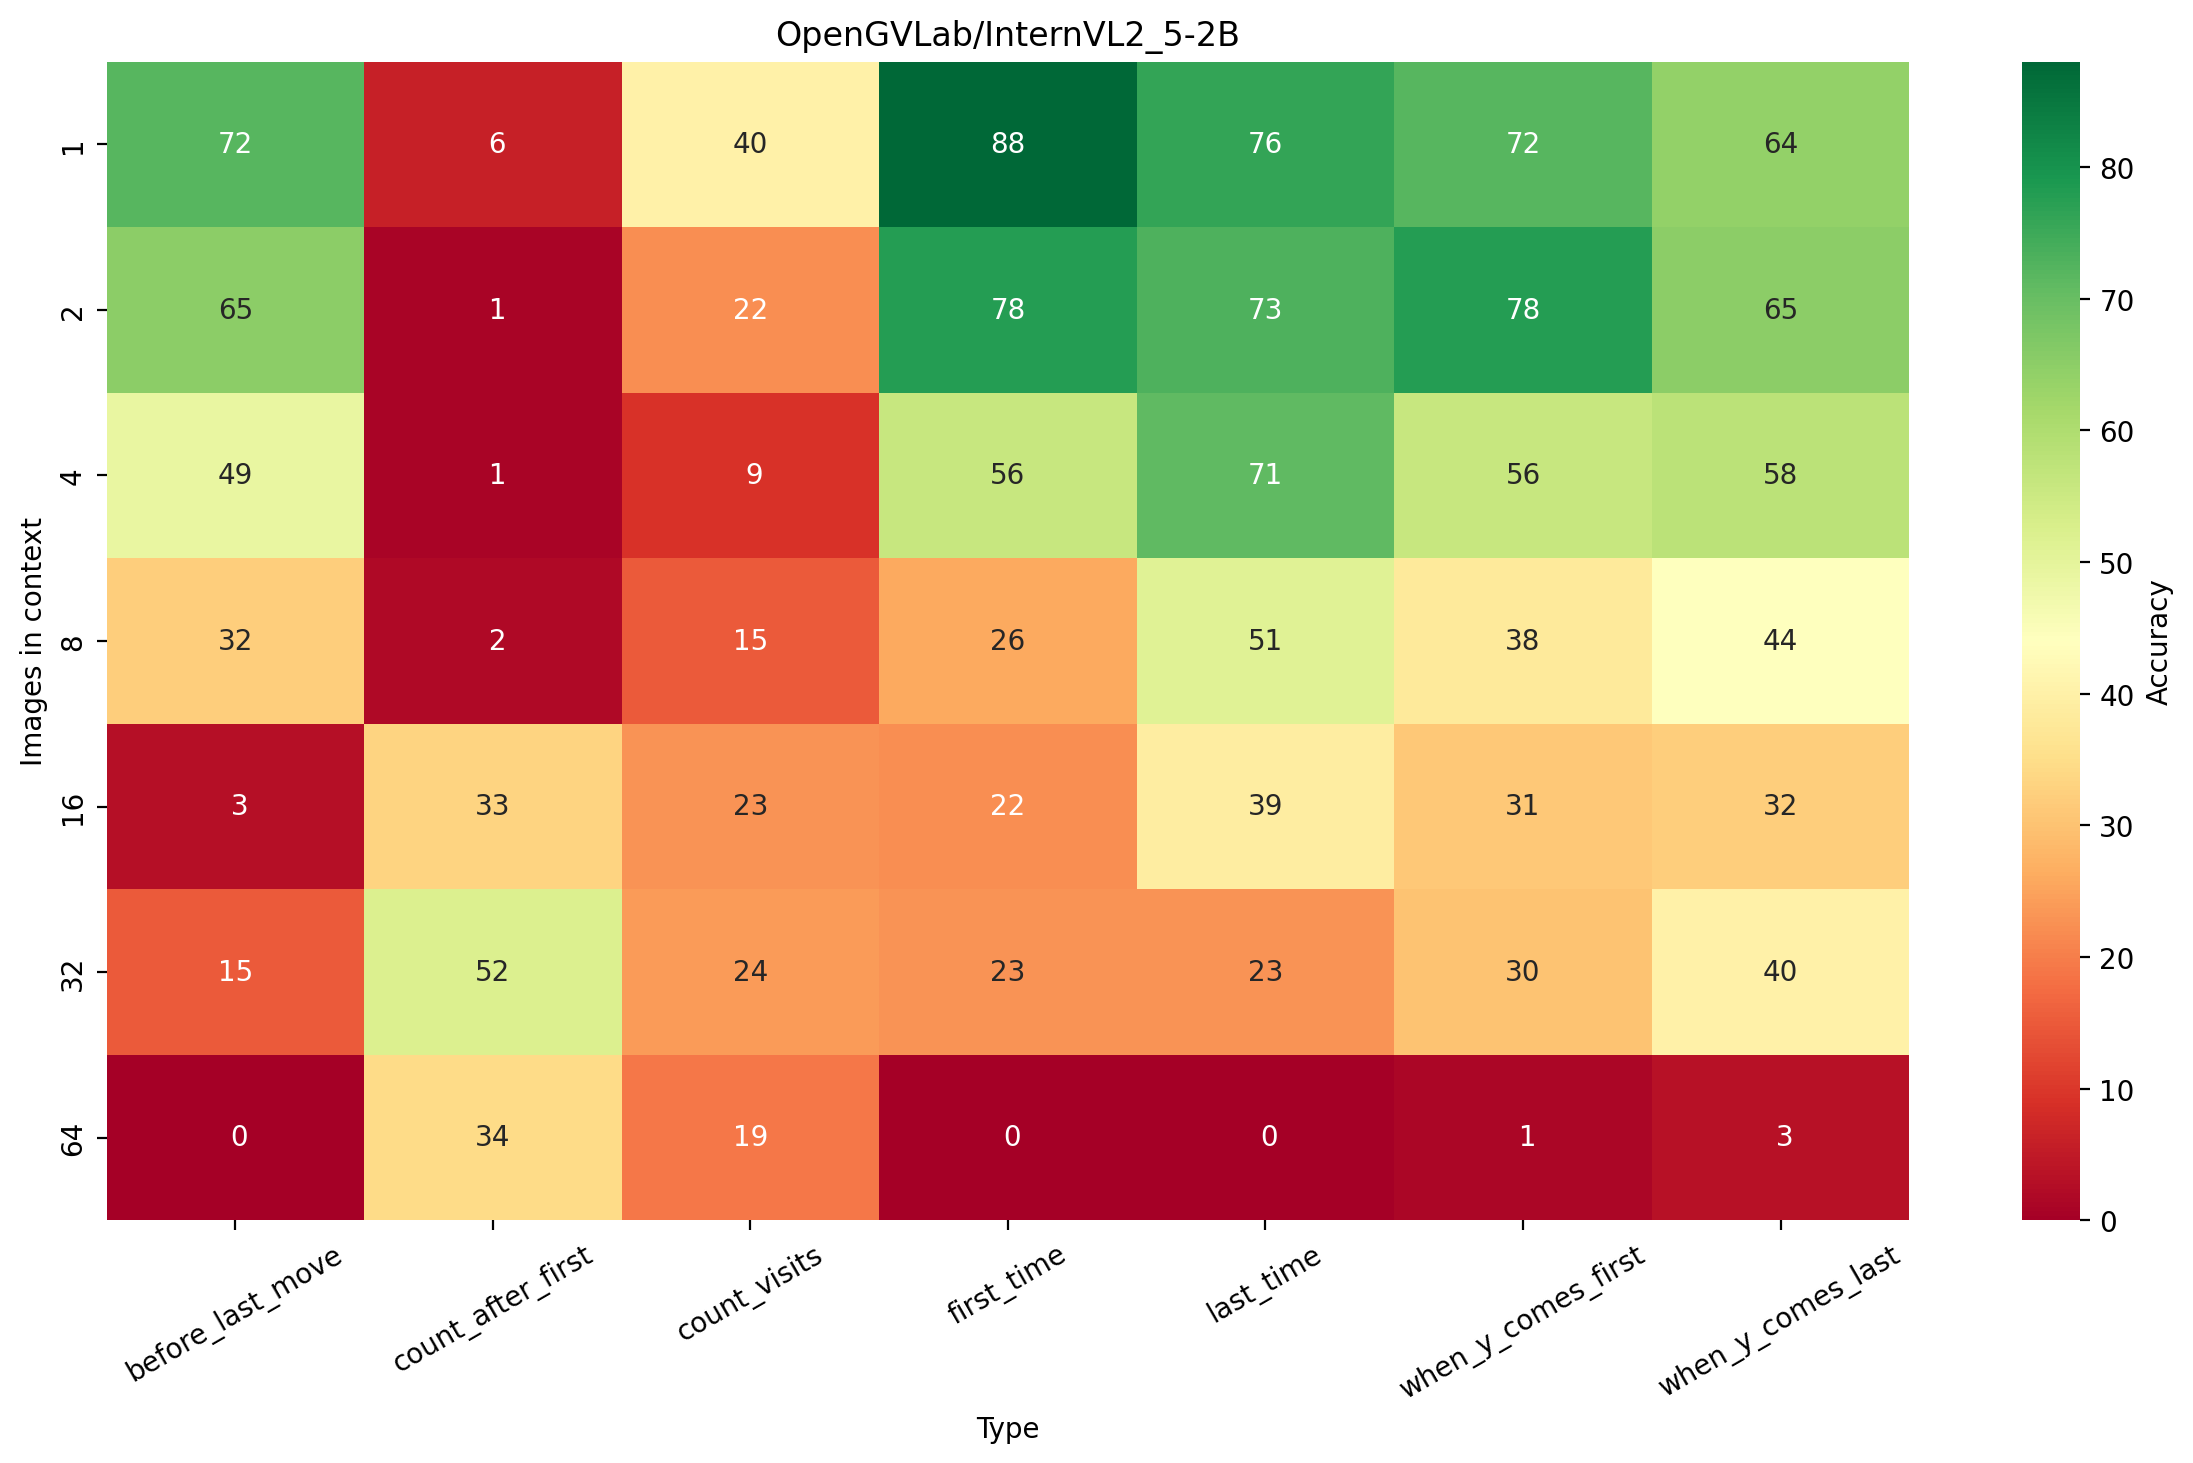

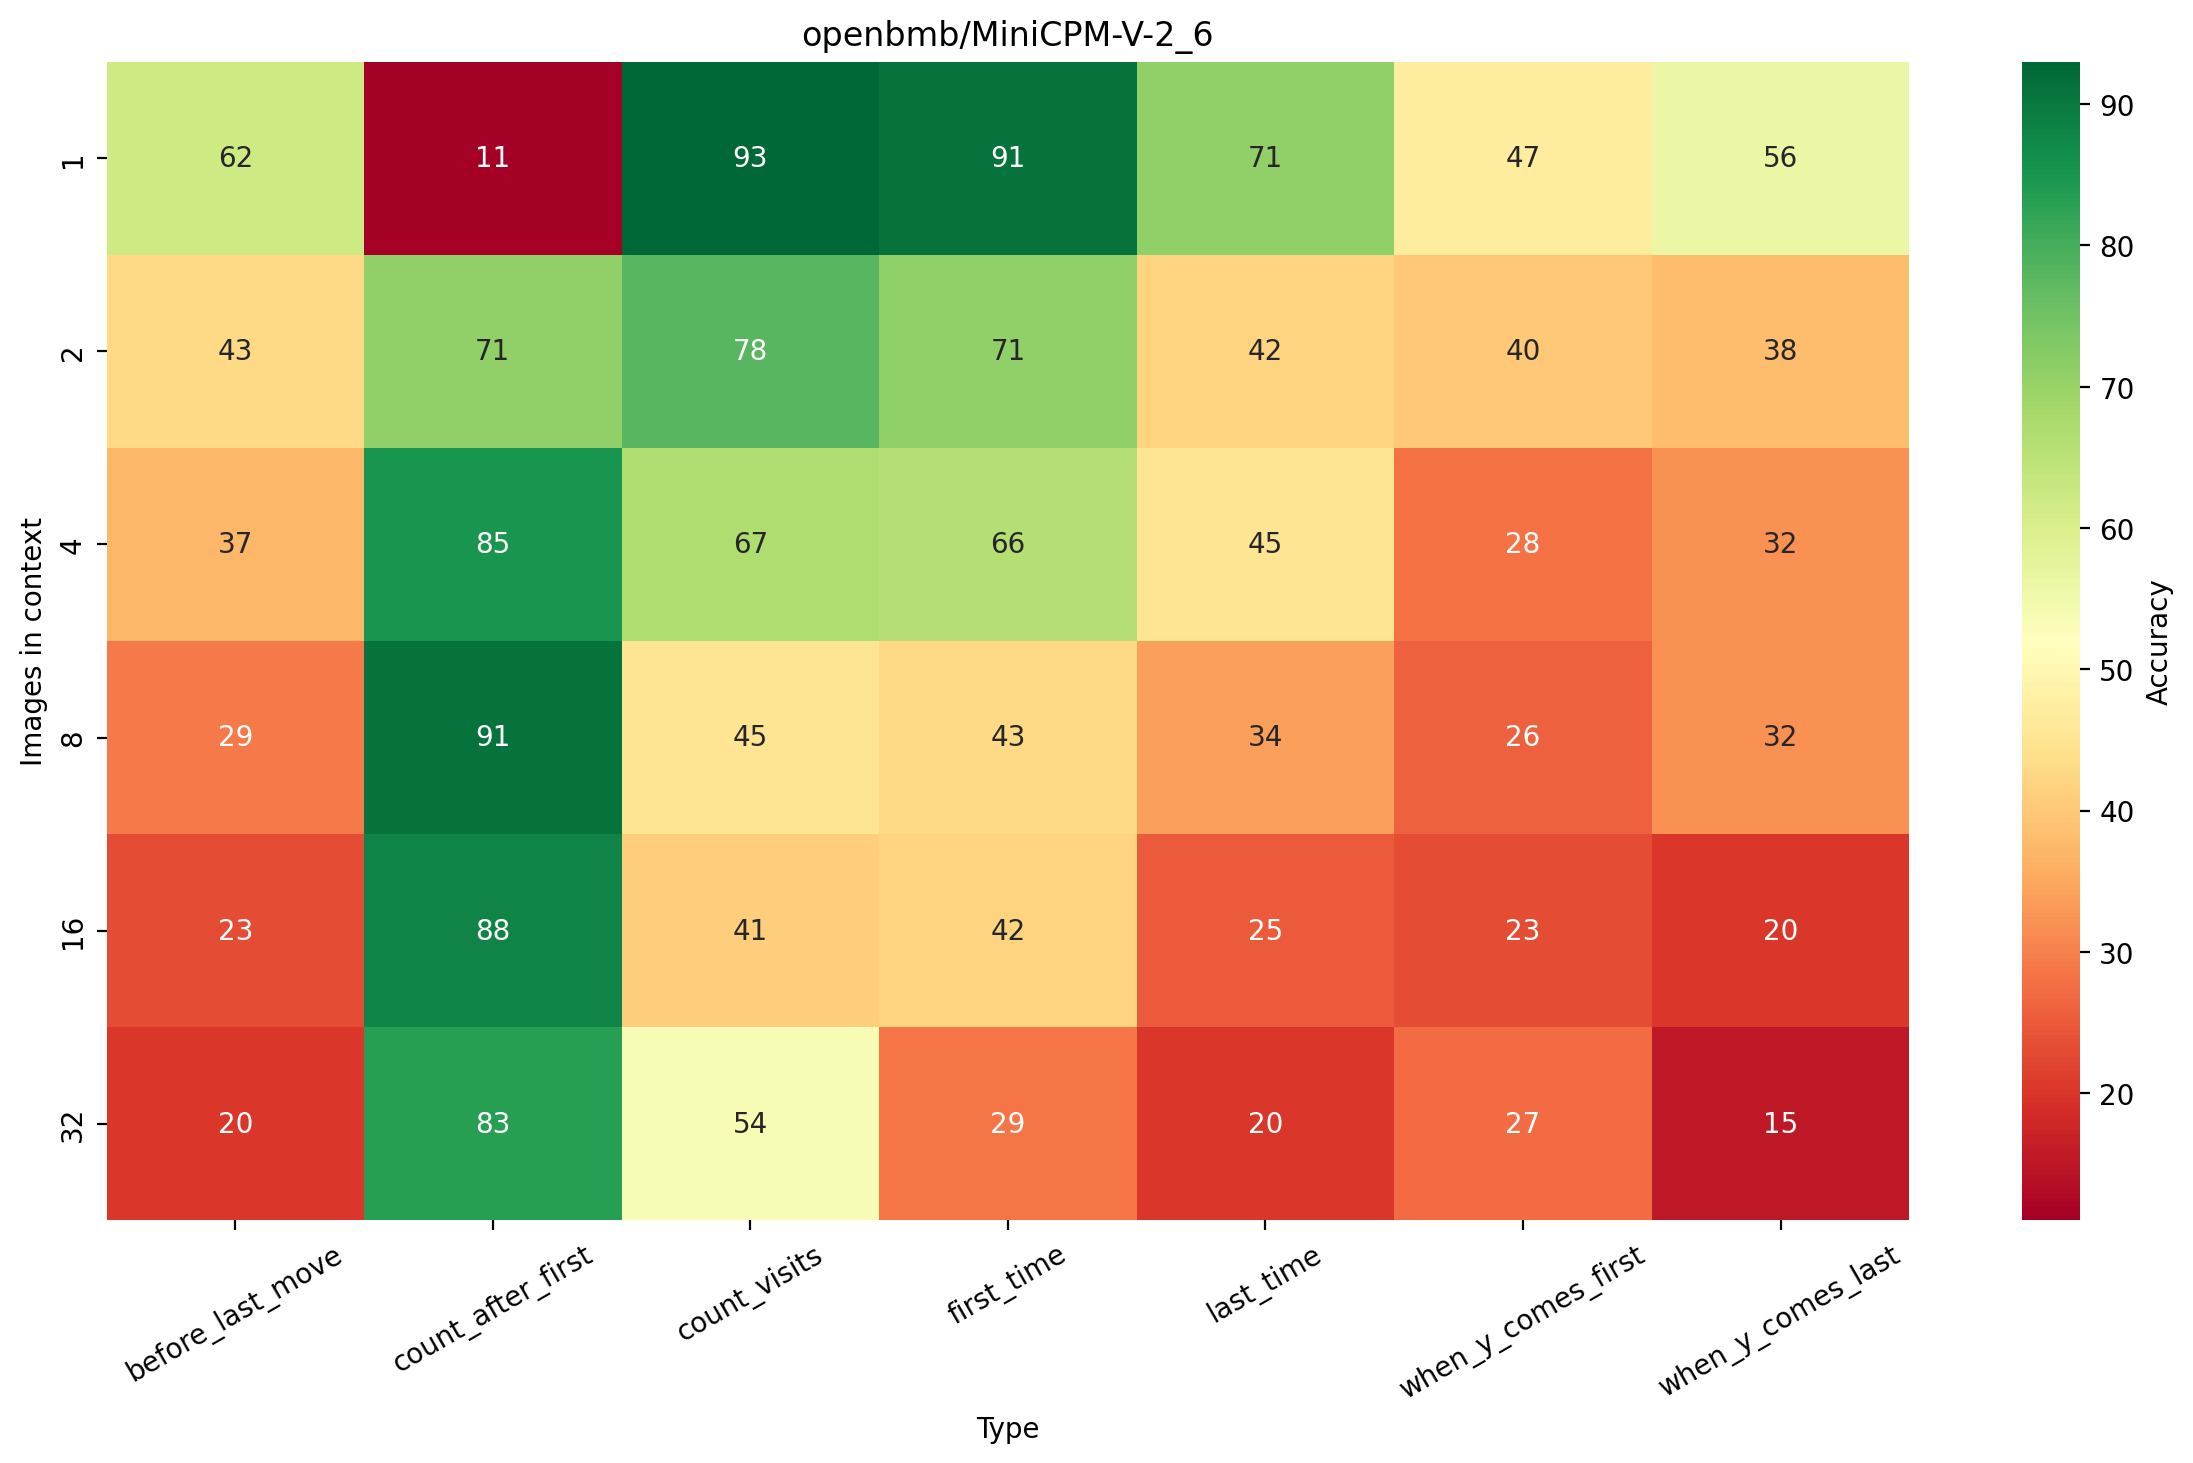

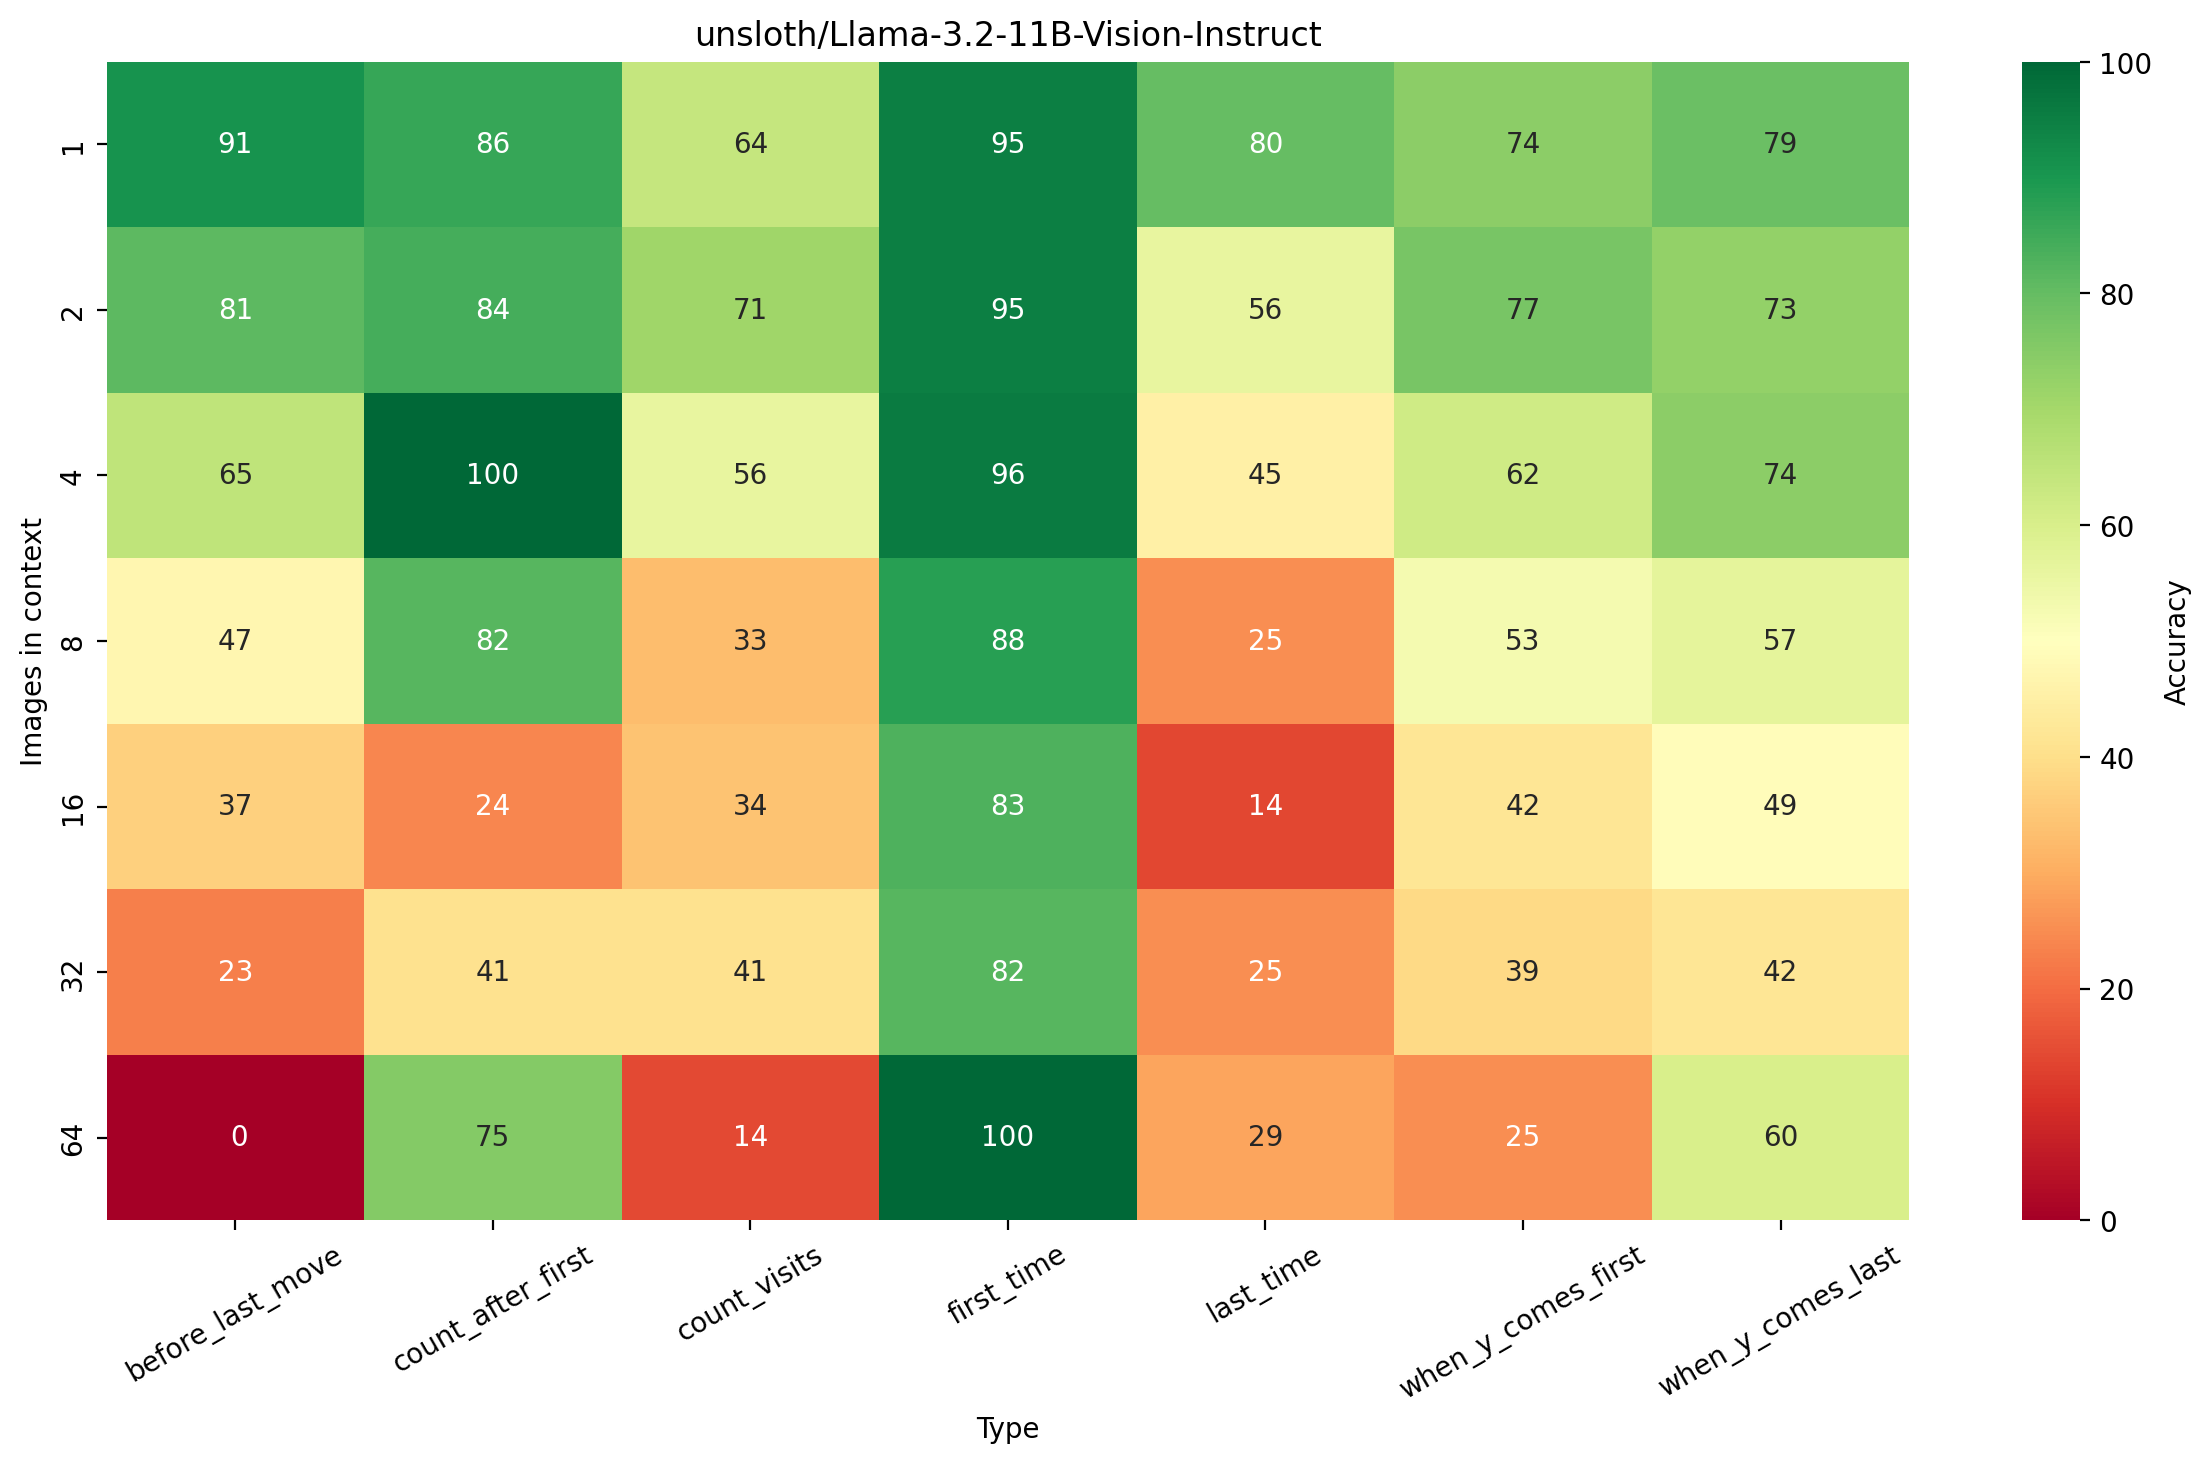

In [14]:
for model in heatmap_data.index.get_level_values("model").unique():
    # Plot heatmap with annotation
    custom_cmap = sns.color_palette("RdYlGn", as_cmap=True)

    plt.figure(figsize=(12, 8))
    sns.heatmap((heatmap_data
                 .xs(model, level=2)
                 .reset_index()
                 .pivot(index="N_steps", columns="Type", values="hit")
                ), annot=True, fmt="2.0f", cmap=custom_cmap, cbar_kws={'label': 'Accuracy'})
    # plt.xlabel('Model')
    plt.ylabel('Images in context')
    plt.title(model)
    plt.tight_layout()
    plt.xticks(rotation=30)
    
    plt.savefig("mmlong.png", bbox_inches="tight")
    plt.show()

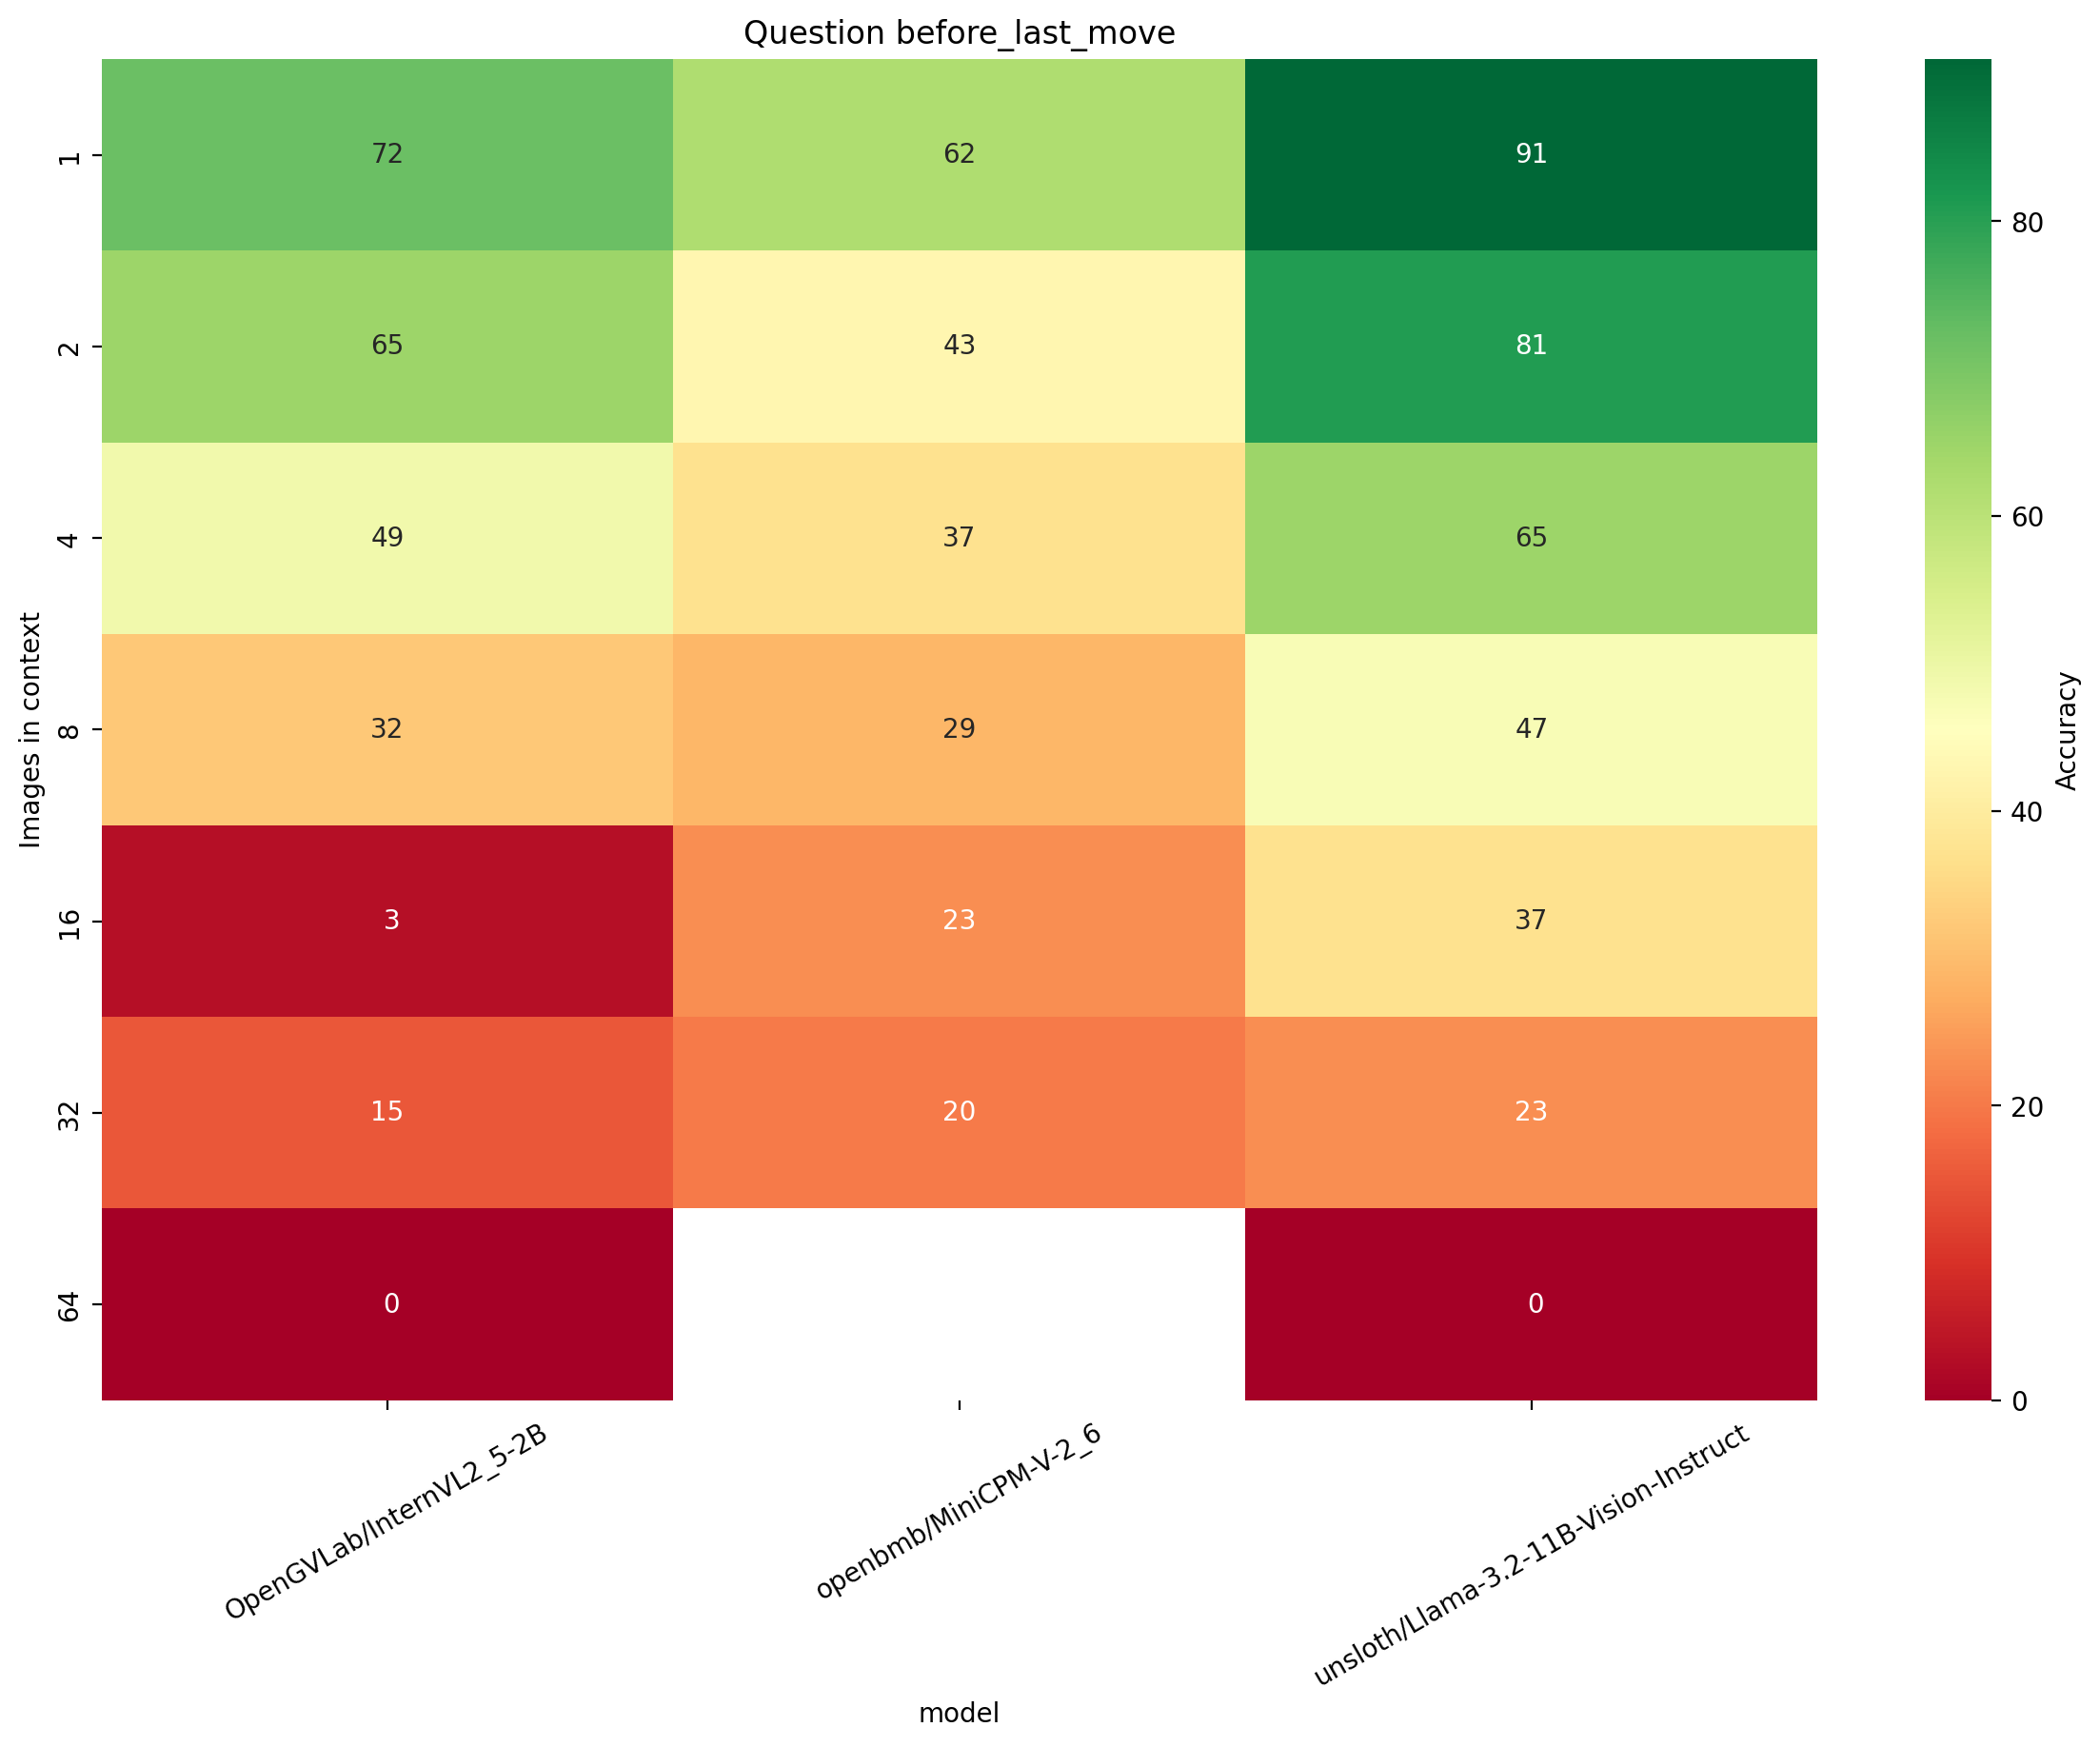

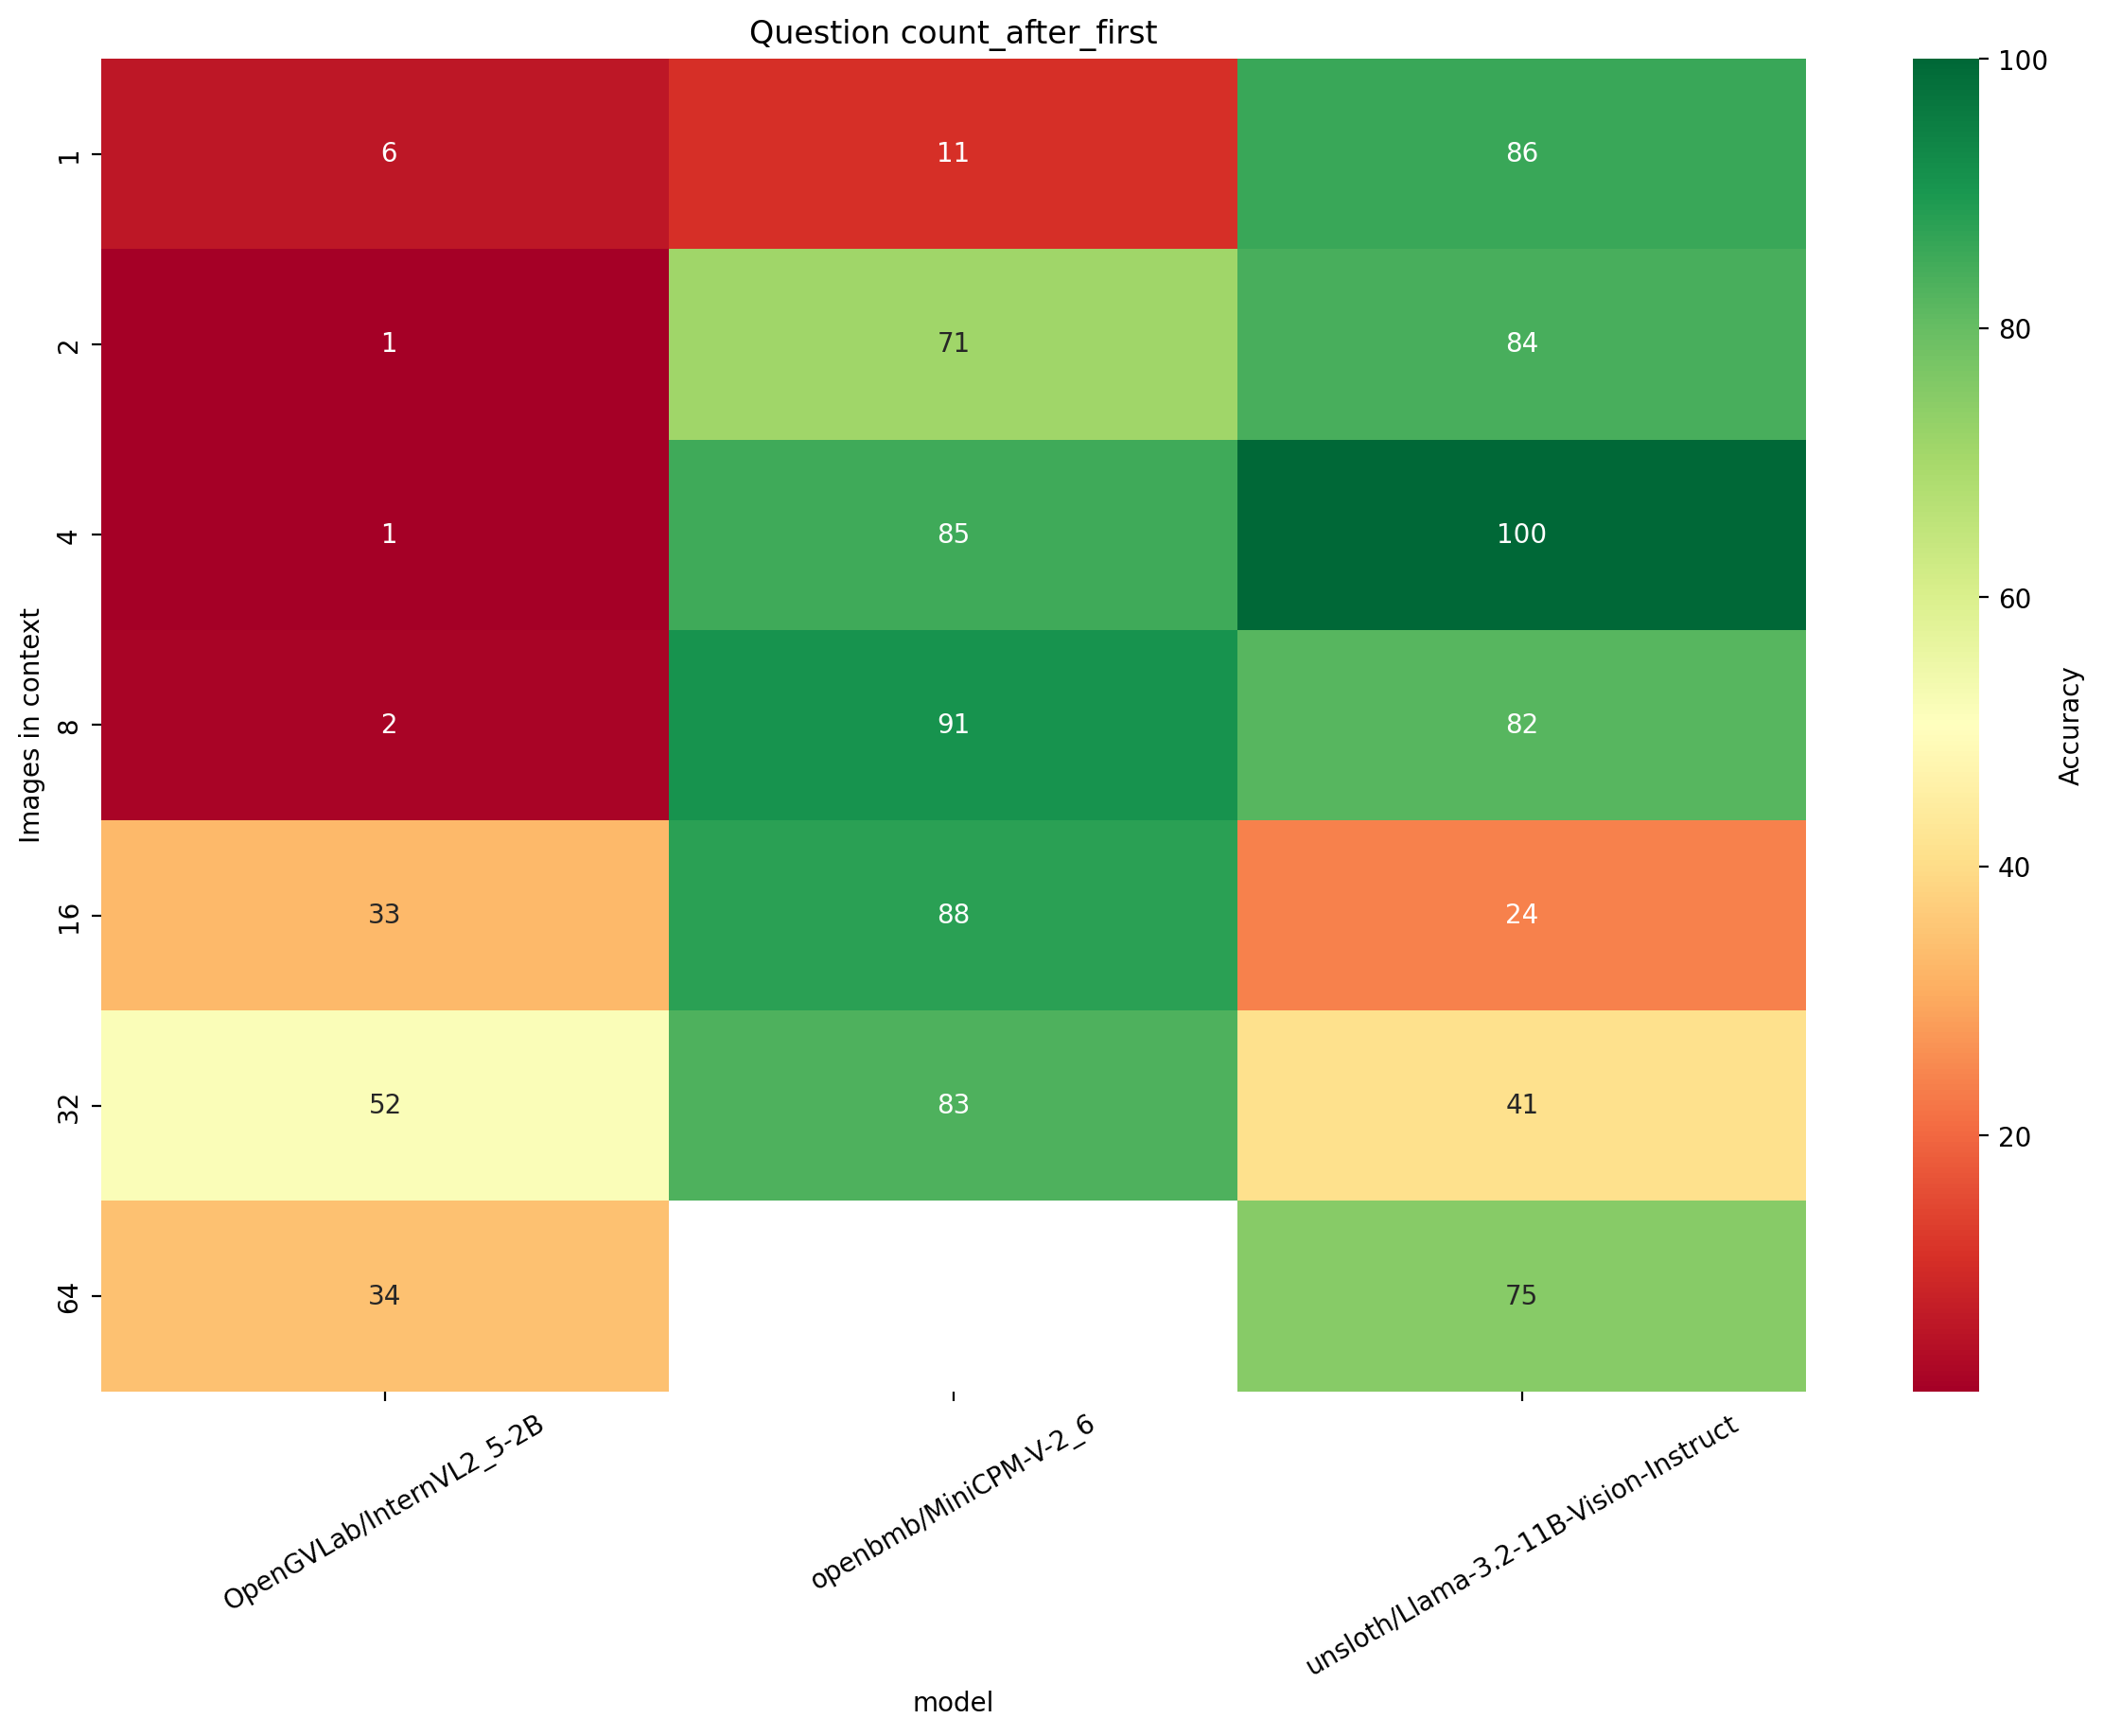

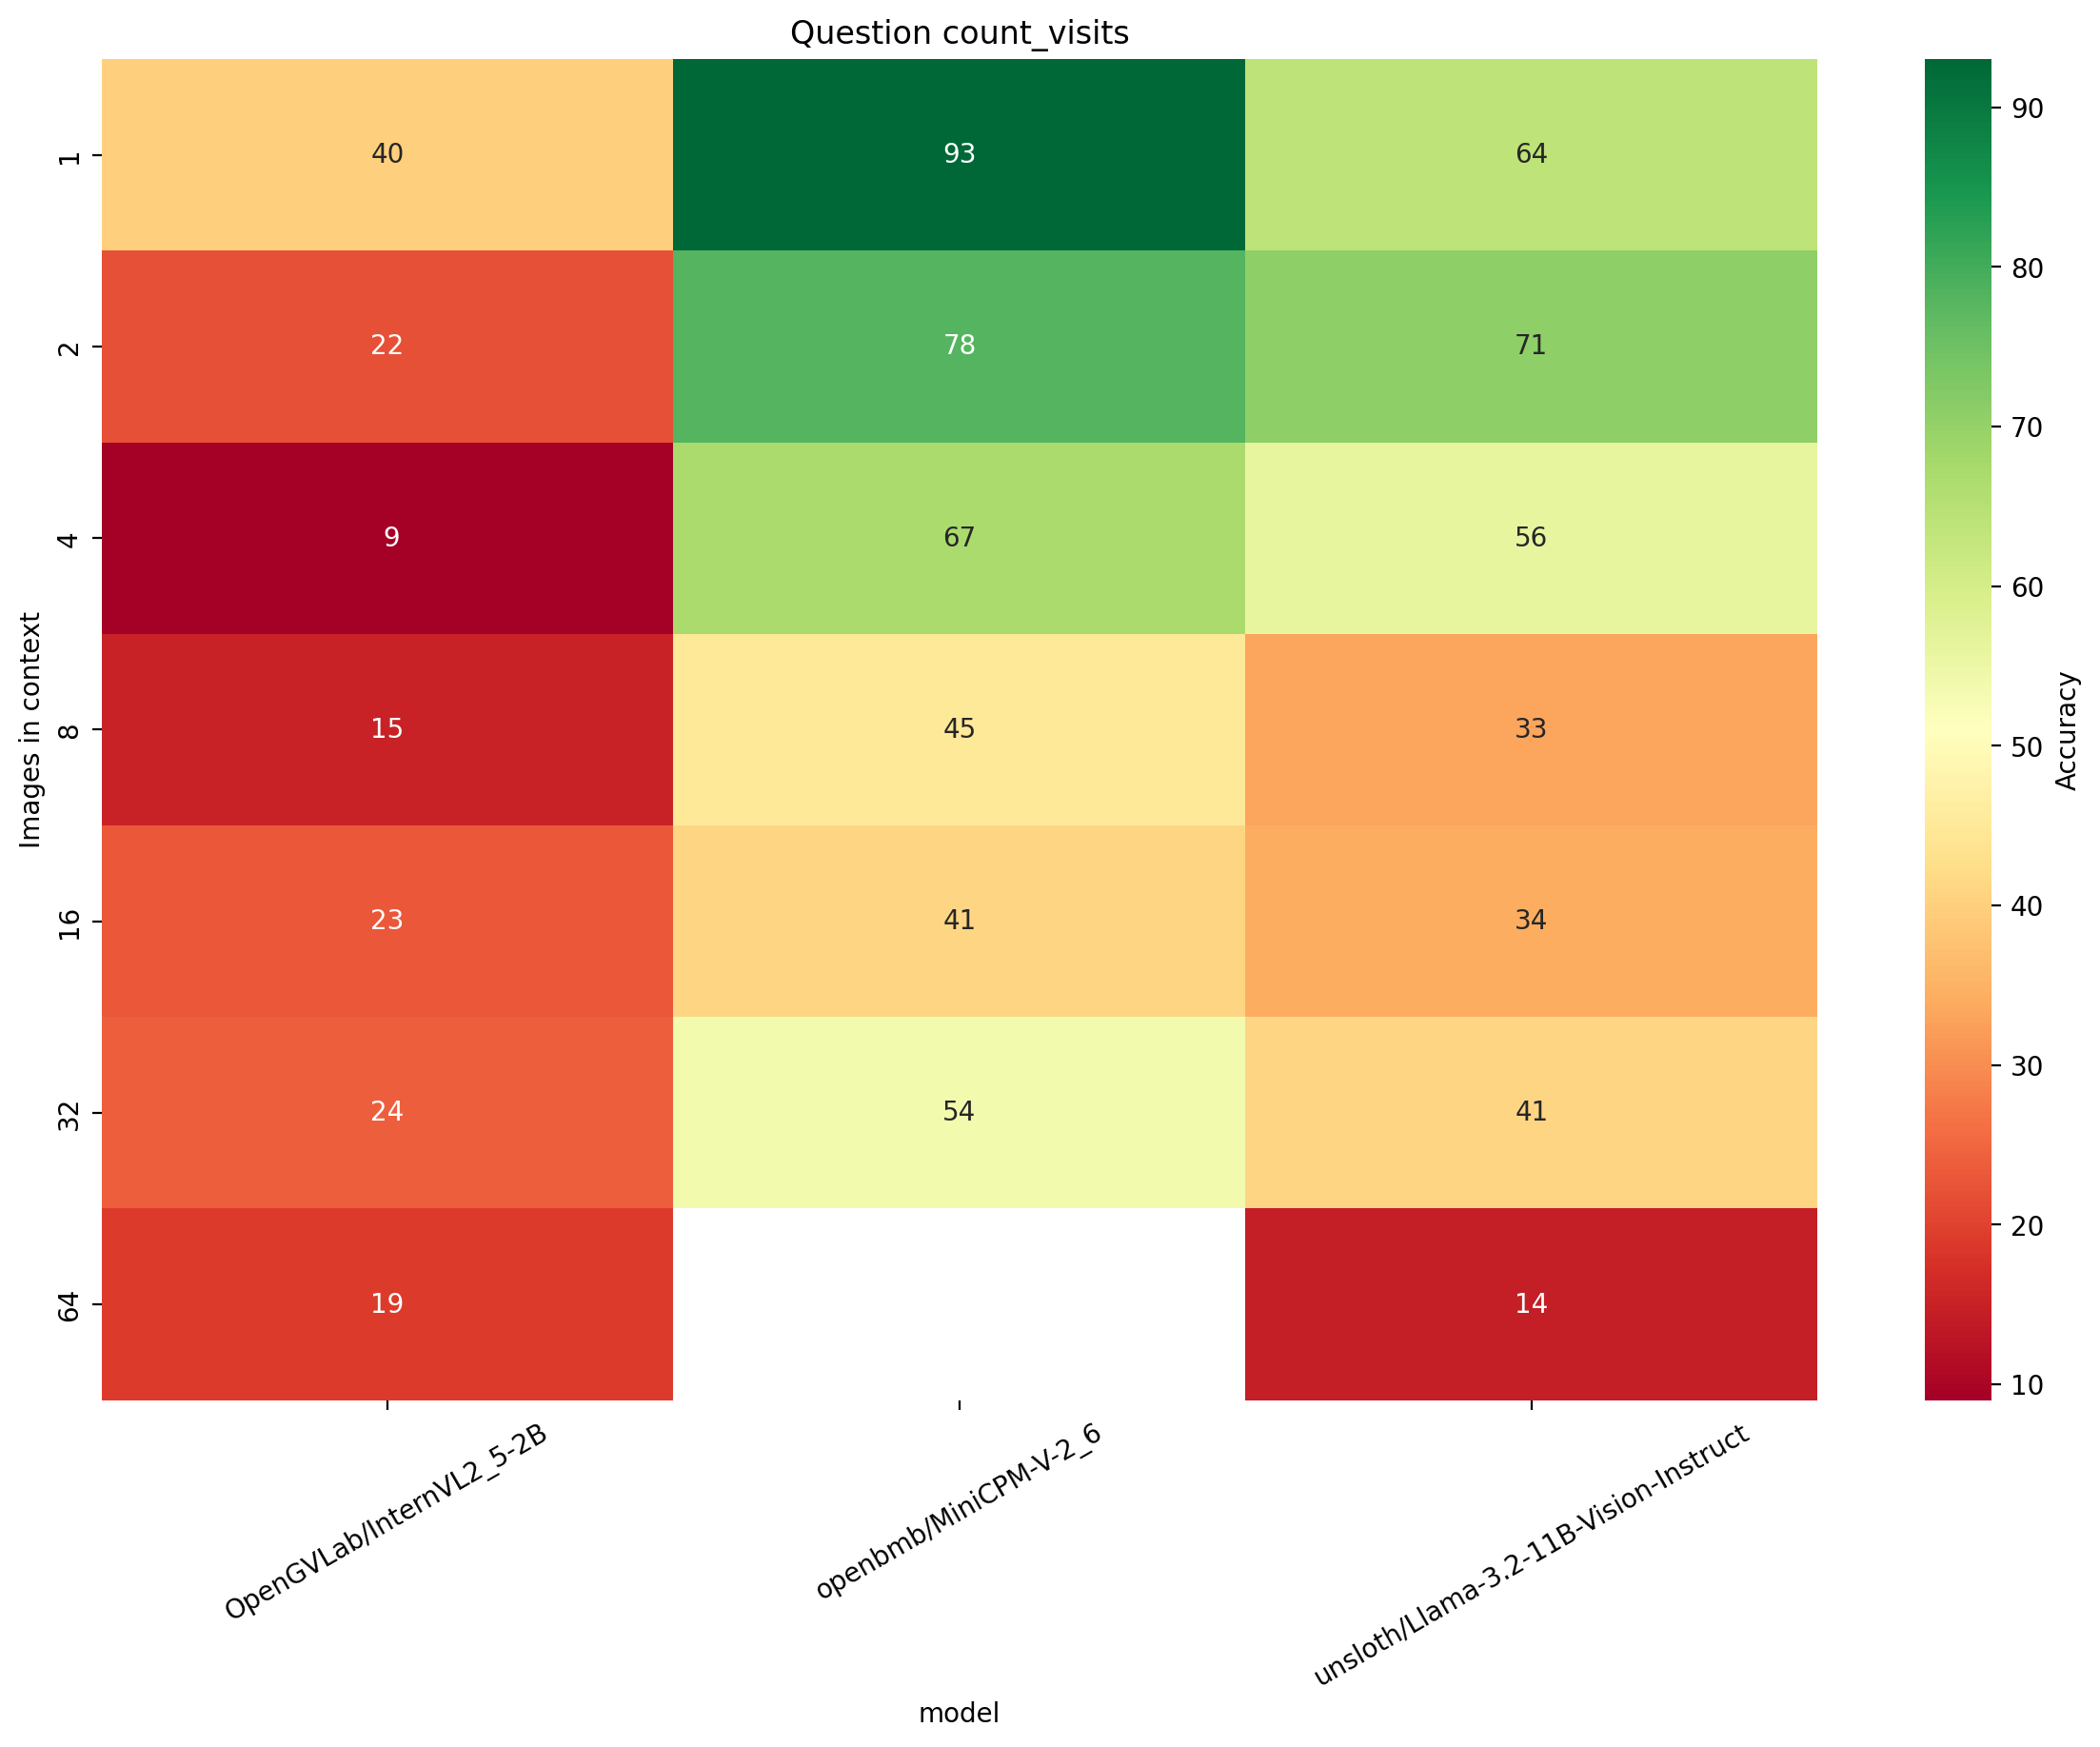

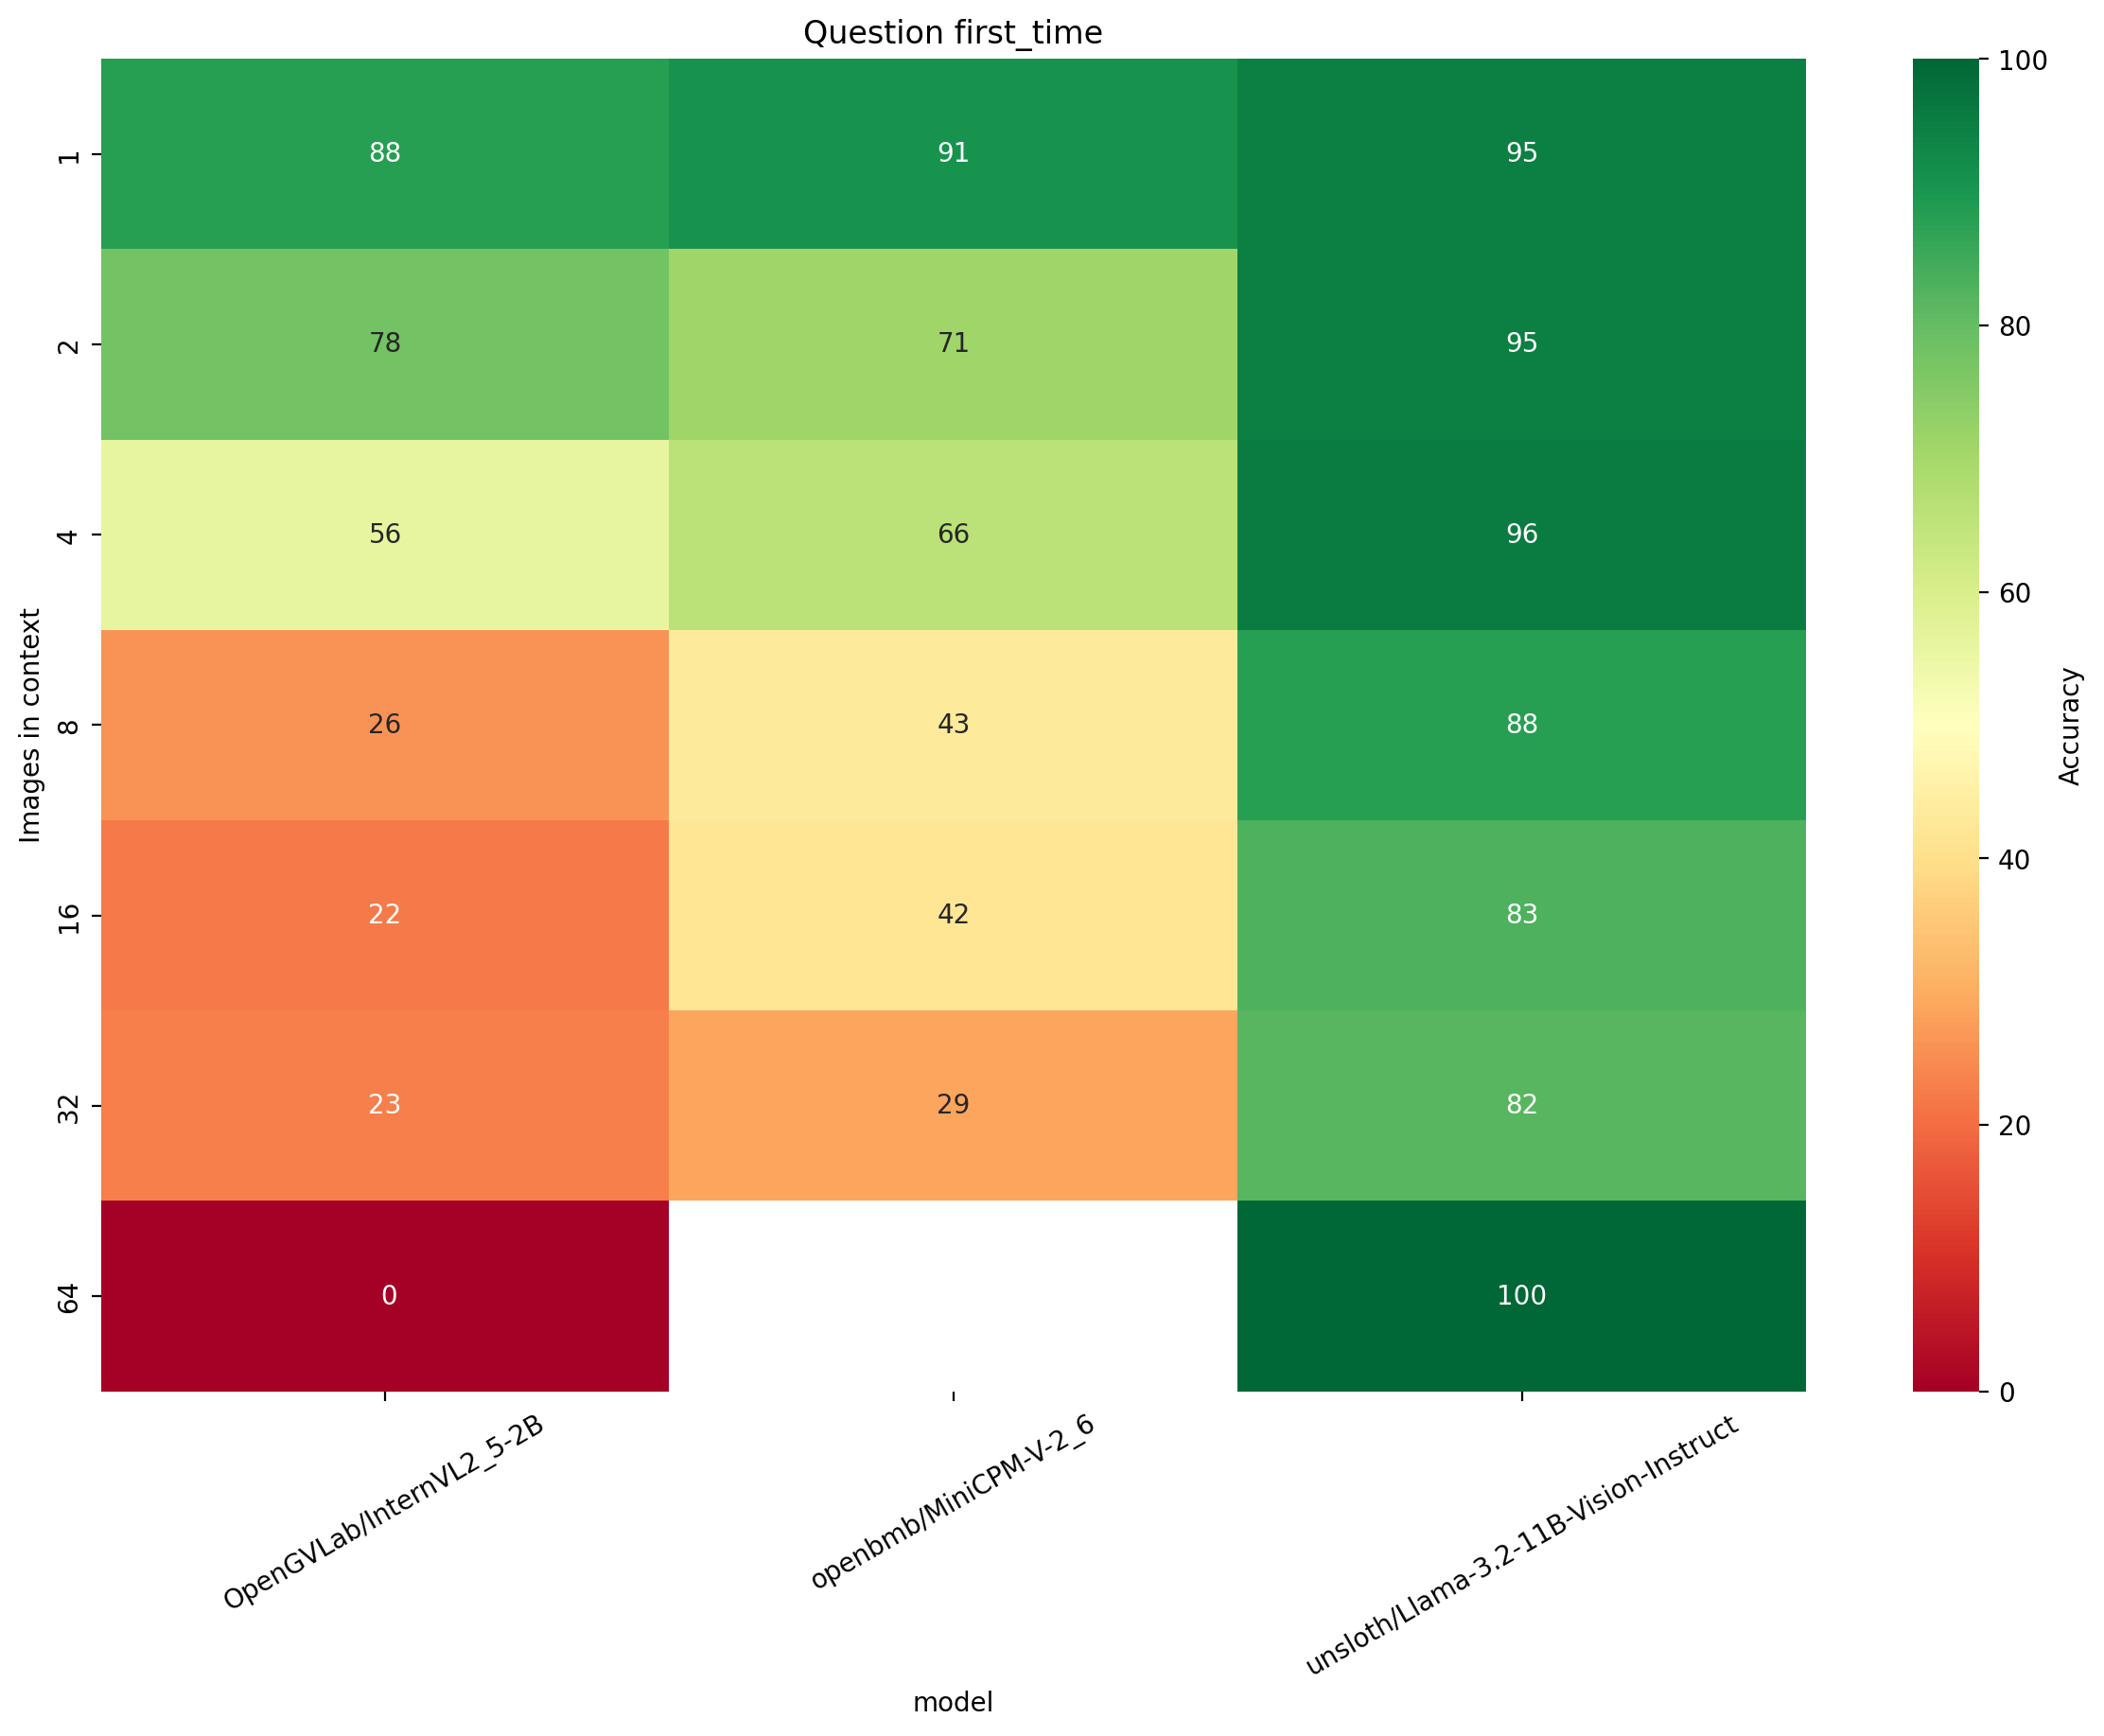

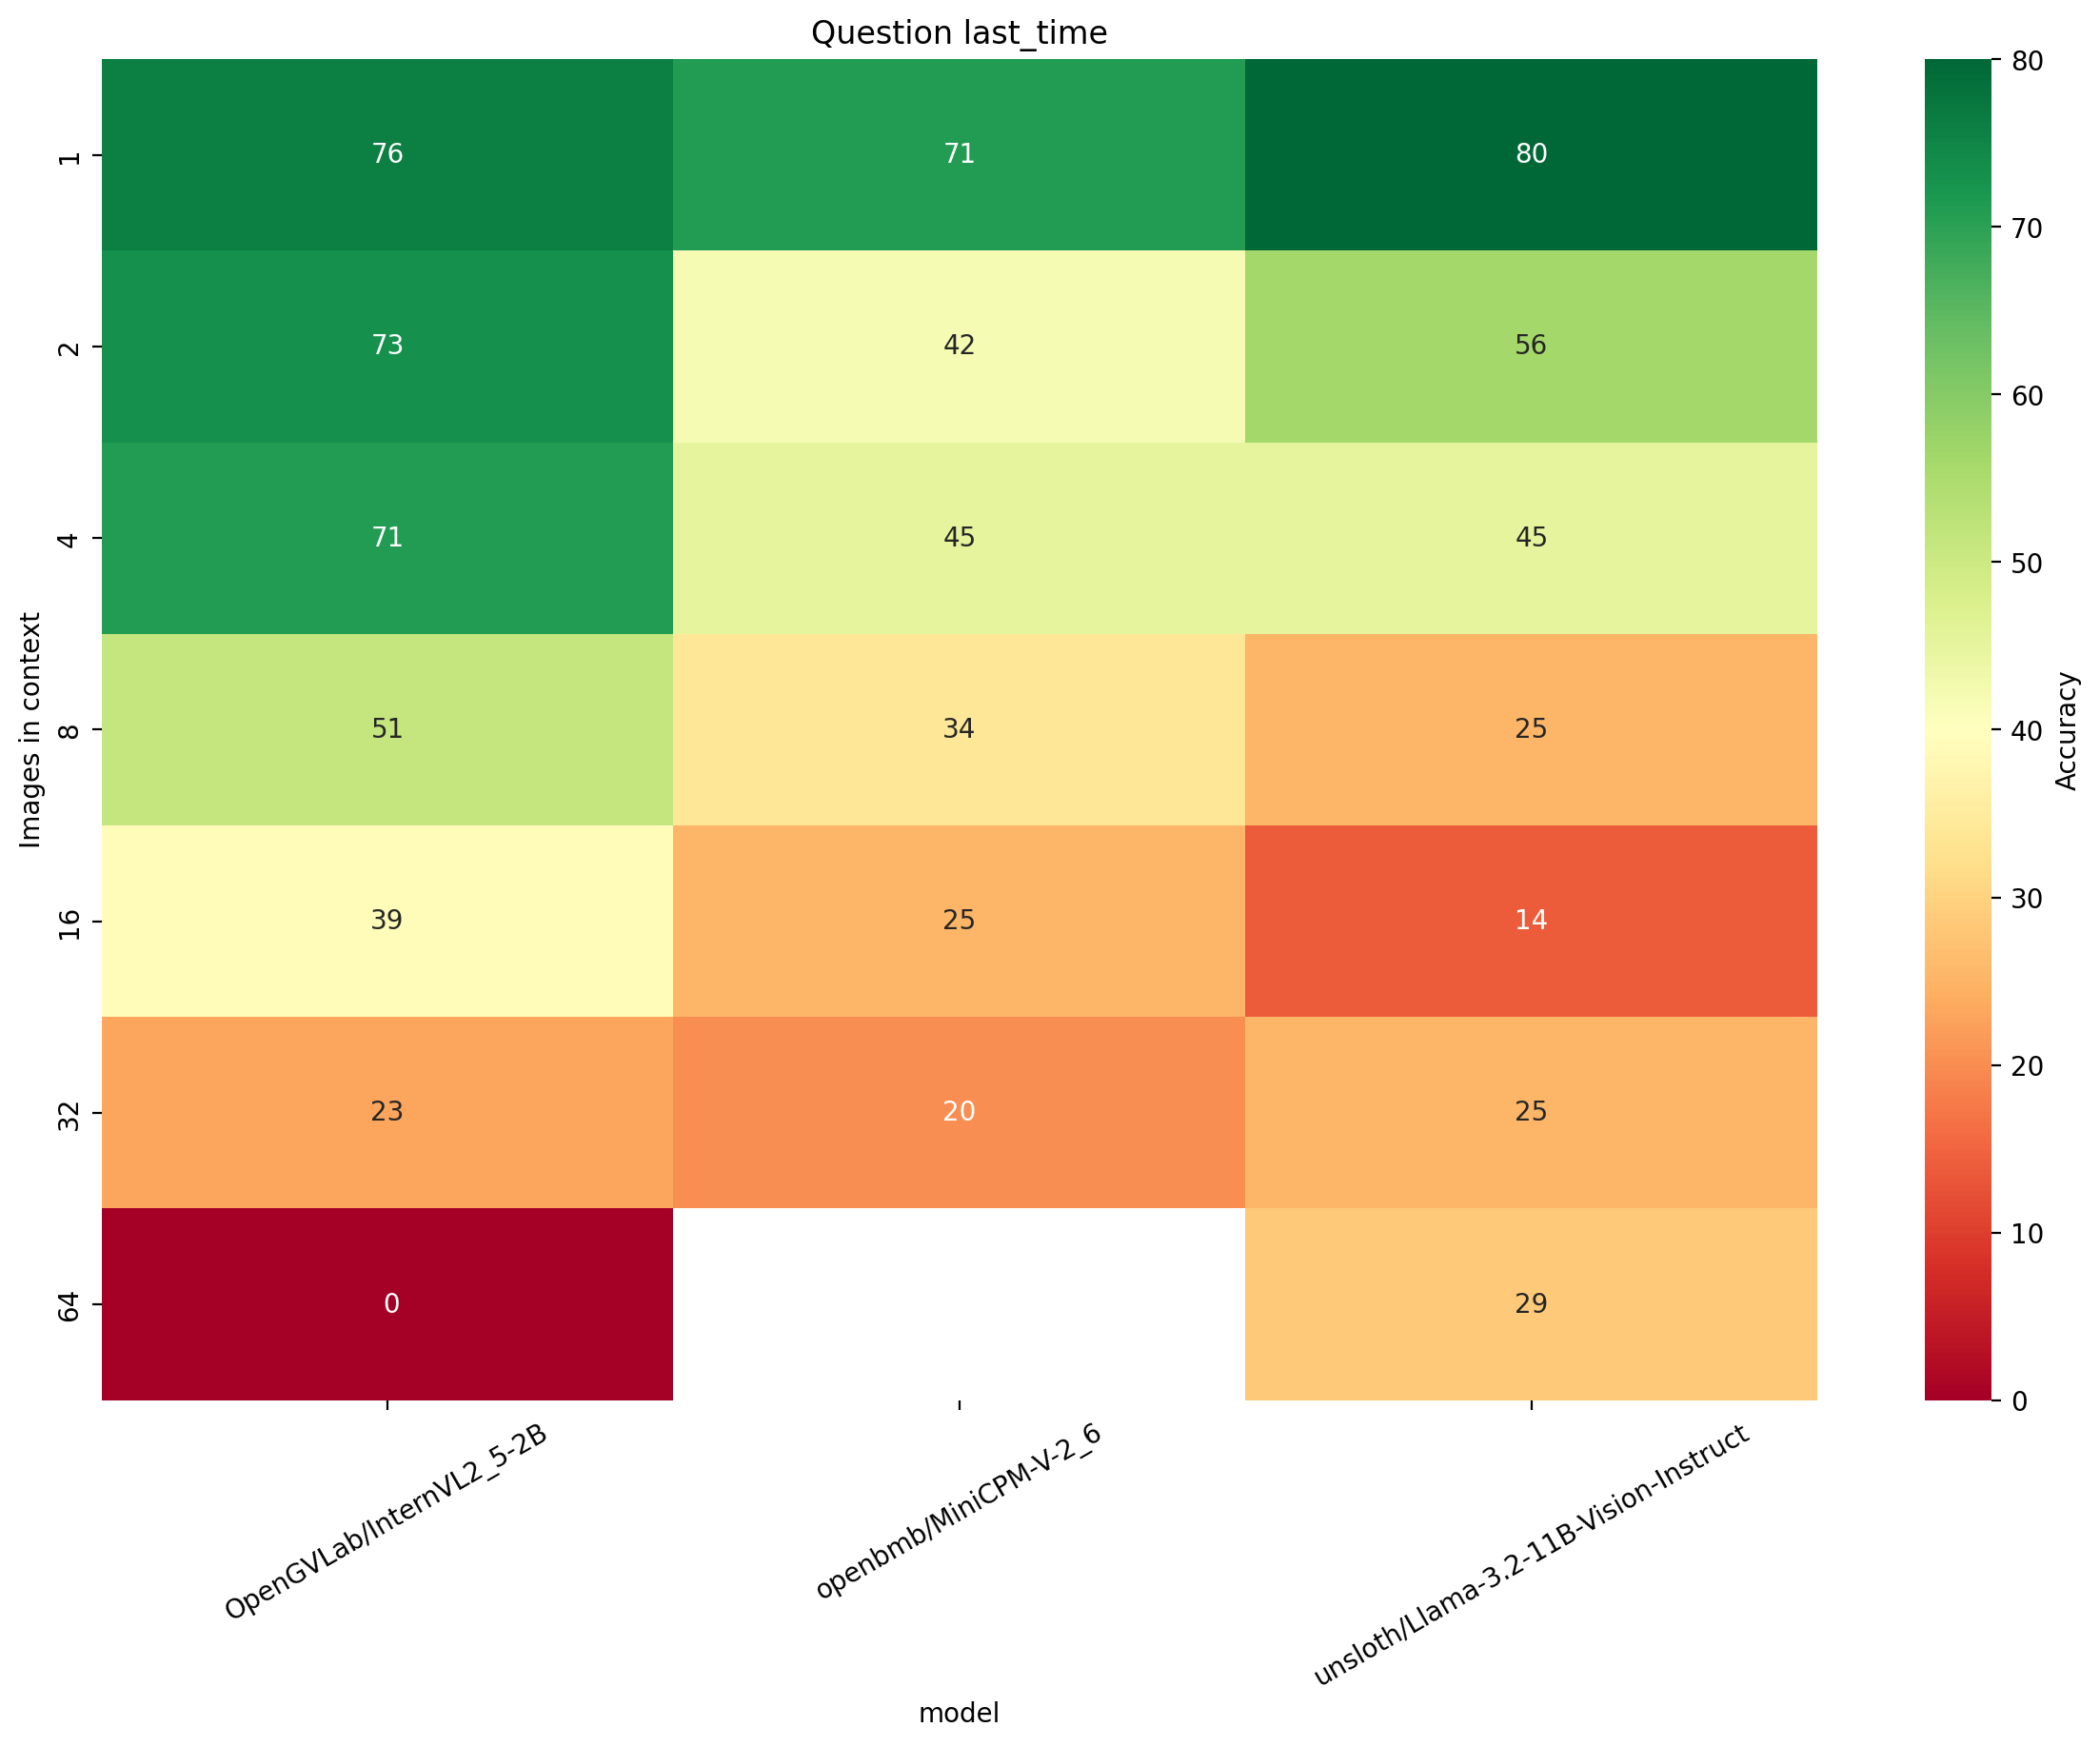

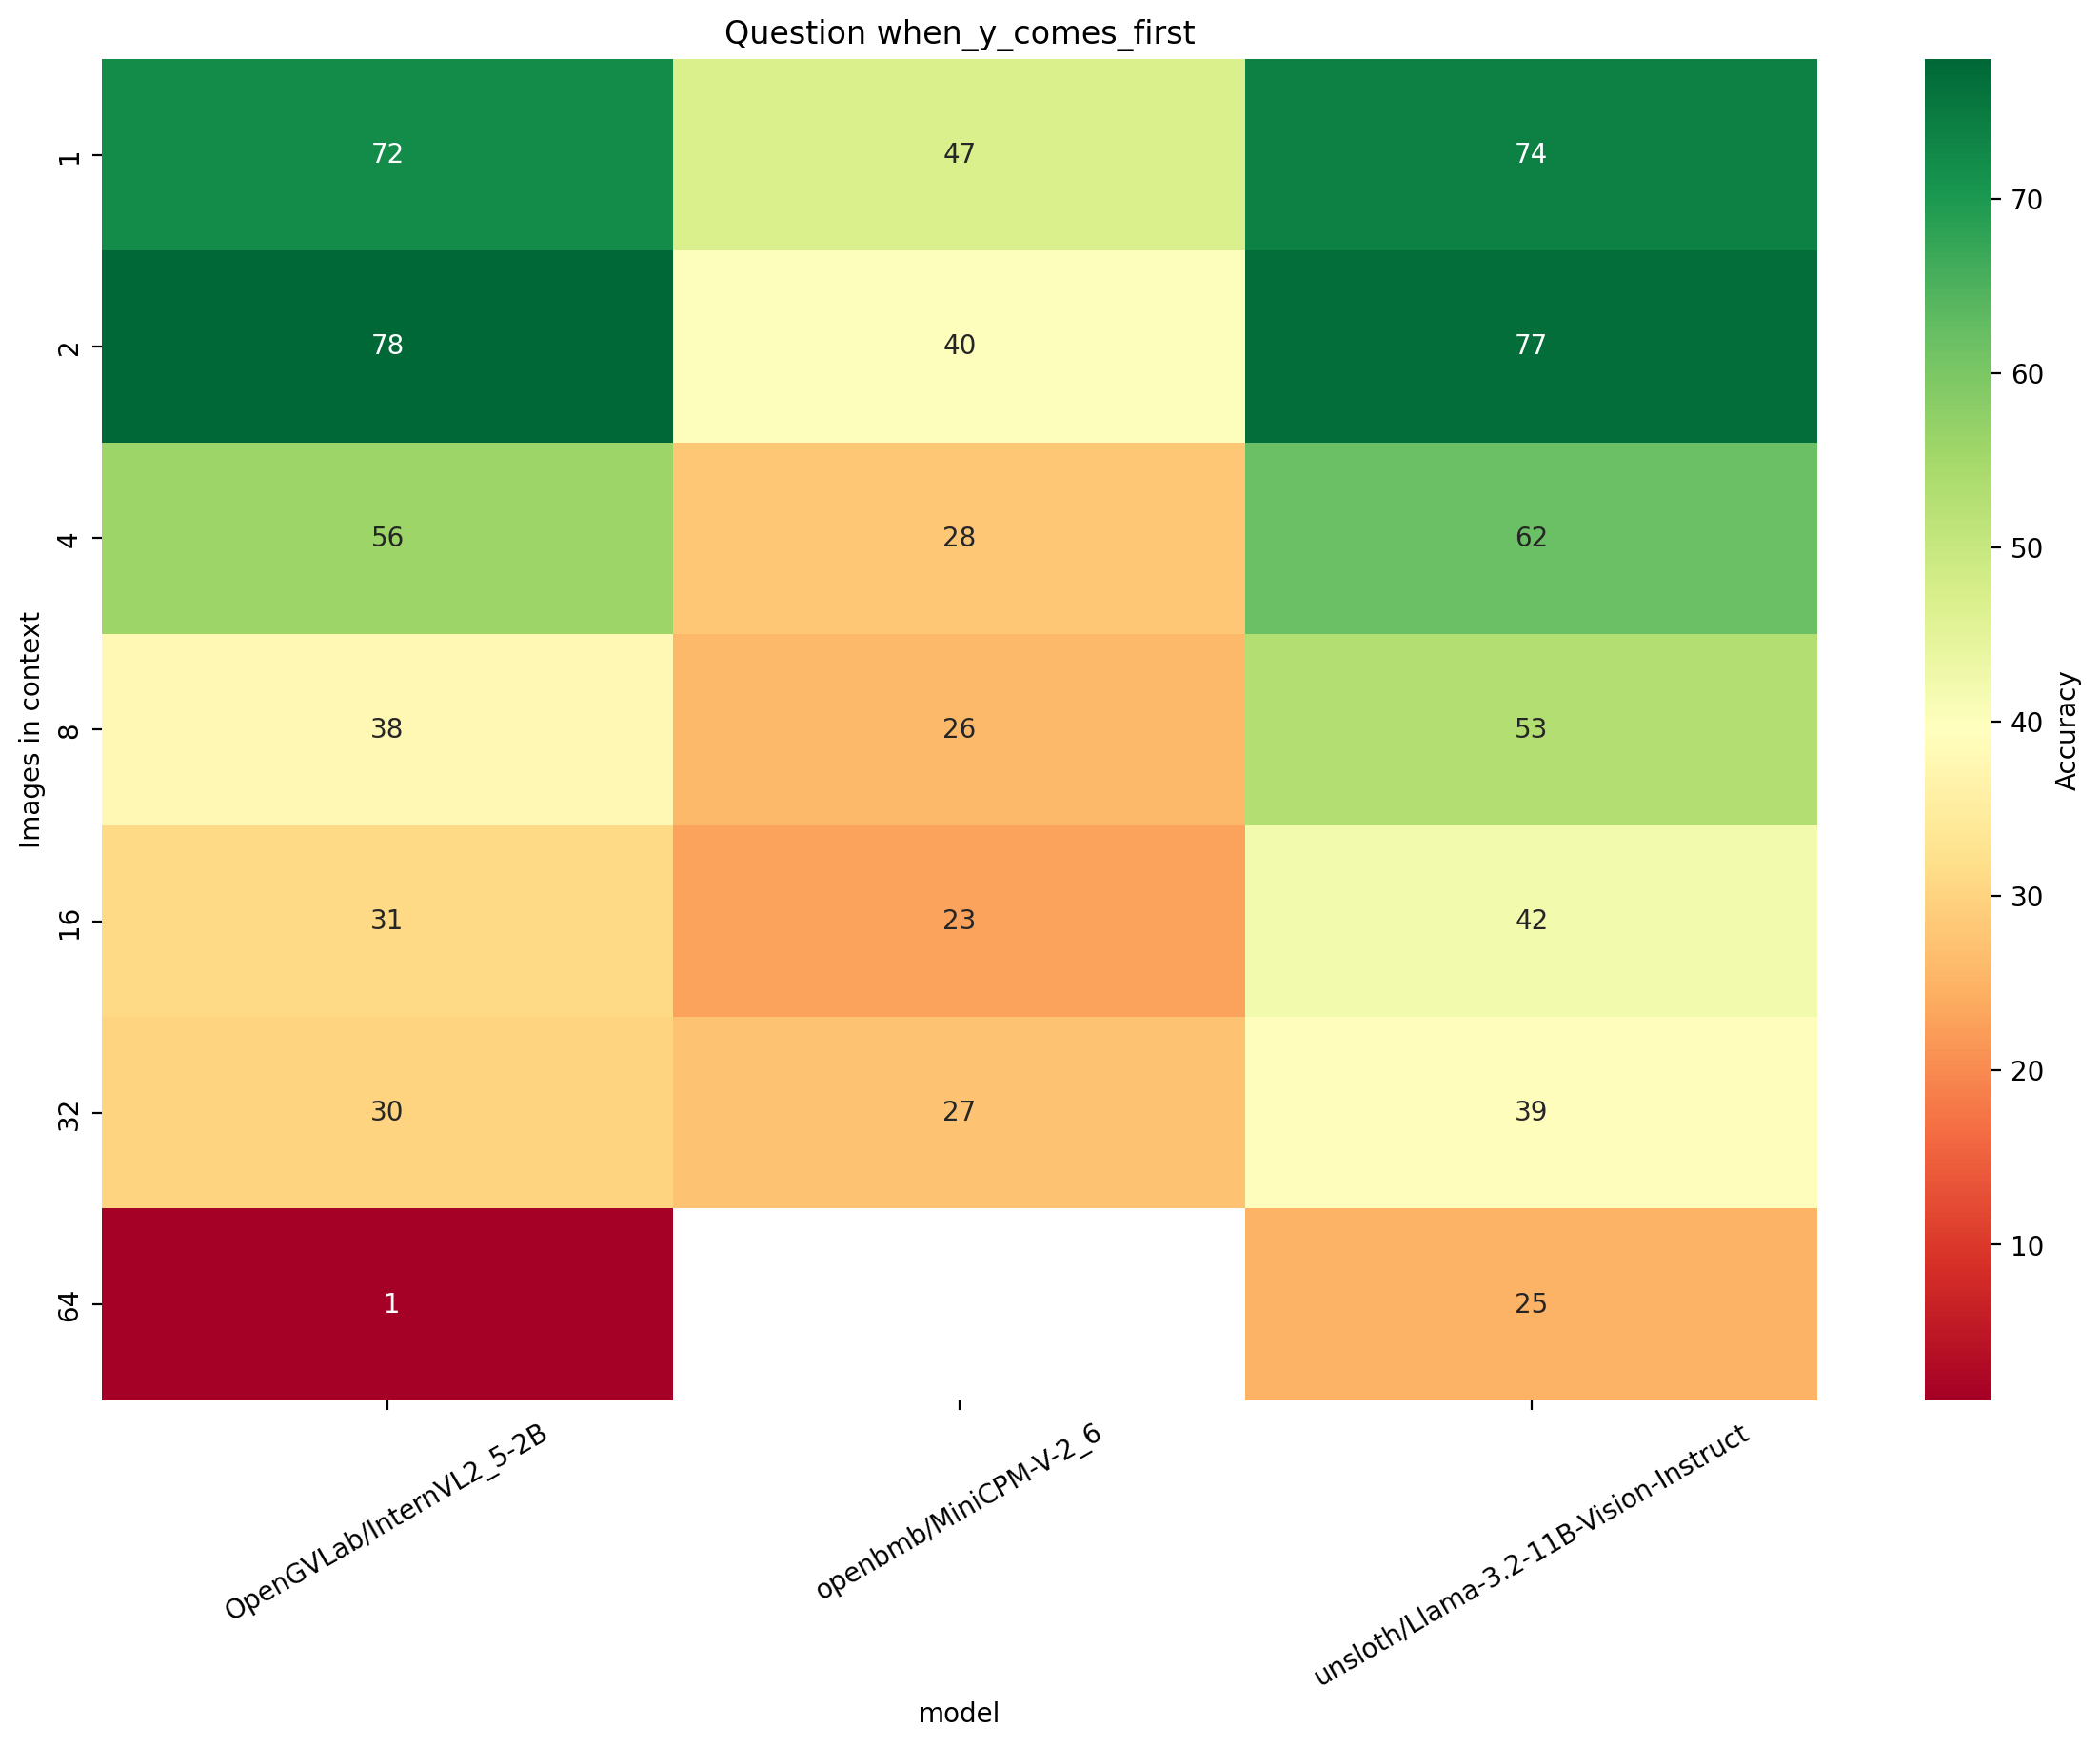

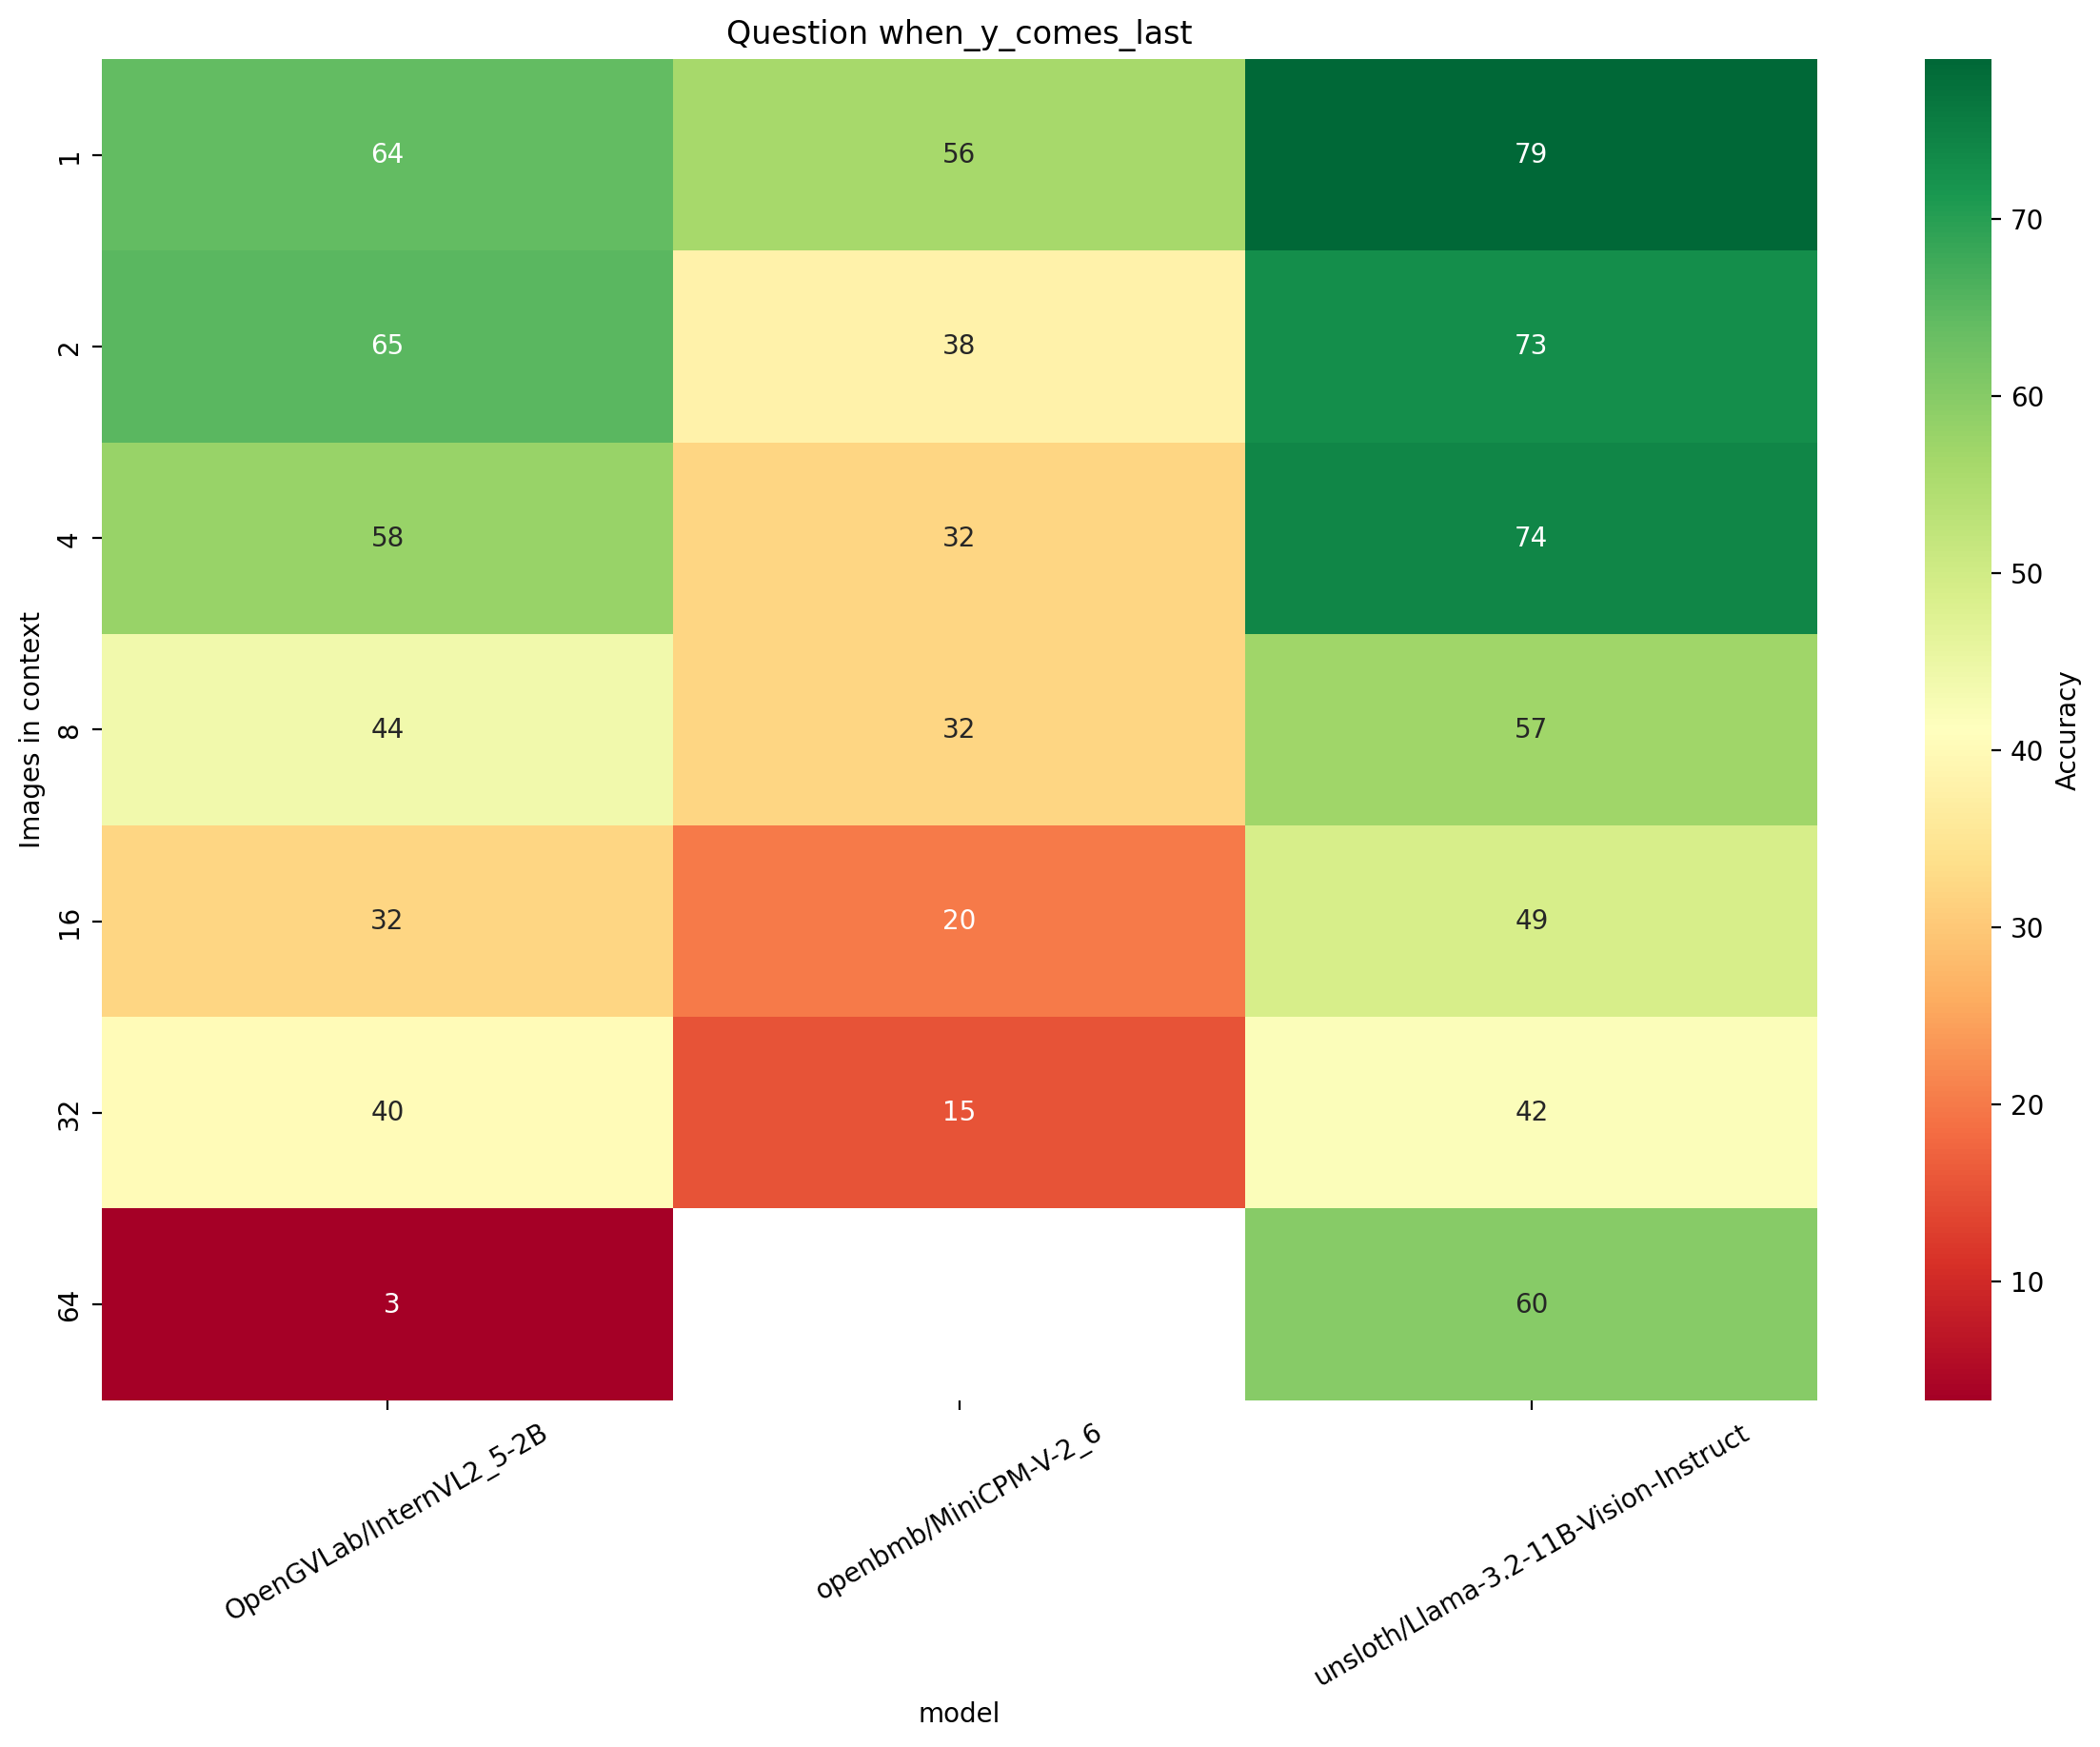

In [15]:
gbs = heatmap_data.groupby('Type')

for name, group in gbs:
    # Plot heatmap with annotation
    custom_cmap = sns.color_palette("RdYlGn", as_cmap=True)
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(group.reset_index().pivot(index="N_steps", columns="model", values="hit"), annot=True, fmt="2.0f", cmap=custom_cmap, cbar_kws={'label': 'Accuracy'})
    # plt.xlabel('Model')
    plt.ylabel('Images in context')
    plt.title(f"Question {name}")
    plt.tight_layout()
    plt.xticks(rotation=30)
    
    plt.savefig("mmlong.png", bbox_inches="tight")
    plt.show()

In [9]:
import os
import glob
import random
import pandas as pd
from collections import defaultdict

##############################################################################
# 1. Load CSVs
##############################################################################

def load_sequence_data(folder="data"):
    """
    Loads all CSV files from 'folder' matching 'sequence_*.csv'
    and returns a dict of DataFrames keyed by filename.
    Each DataFrame is assumed to have columns: [Step, Character, Room].
    """
    data_files = sorted(glob.glob(os.path.join(folder, "sequence_*.csv")))
    all_sequences = {}
    
    for file_path in data_files:
        file_name = os.path.basename(file_path)
        df = pd.read_csv(file_path)

        expected_cols = ["Step", "Character", "Room"]
        if not all(col in df.columns for col in expected_cols):
            raise ValueError(f"File {file_path} must have columns {expected_cols}.")
        
        df = df.sort_values(by="Step").reset_index(drop=True)
        all_sequences[file_name] = df
    
    return all_sequences

##############################################################################
# 2. Truncate Data
##############################################################################

def truncate_data_by_step_size(df, step_size):
    """
    Returns a truncated version of 'df' with all rows where Step <= step_size.
    """
    truncated = df[df["Step"] <= step_size].copy()
    truncated.reset_index(drop=True, inplace=True)
    return truncated

##############################################################################
# 3. Build a Timeline: step -> {char: room}
##############################################################################

def build_timeline(df):
    """
    Builds a dict timeline[step] = { character: room, ... }
    for each step from min_step to max_step in df.
    Characters keep their location from the previous step if they don't move.
    Returns (timeline, steps_range).
    """
    if df.empty:
        return {}, []
    
    min_step = df["Step"].min()
    max_step = df["Step"].max()
    all_chars = df["Character"].unique().tolist()

    # Initialize
    timeline = {}
    for s in range(min_step, max_step + 1):
        timeline[s] = {}
    
    df_sorted = df.sort_values("Step").to_dict("records")
    row_idx = 0
    n = len(df_sorted)

    # Start with an empty reference at first
    previous_state = {c: None for c in all_chars}
    
    for s in range(min_step, max_step + 1):
        # Copy forward from previous step
        # (so each character retains the prior location if they didn't move)
        timeline[s] = dict(previous_state)
        
        # Process rows for this step
        while row_idx < n and df_sorted[row_idx]["Step"] == s:
            char = df_sorted[row_idx]["Character"]
            rm = df_sorted[row_idx]["Room"]
            timeline[s][char] = rm
            row_idx += 1
        
        # Update previous_state
        previous_state = dict(timeline[s])
    
    steps_range = list(range(min_step, max_step + 1))
    return timeline, steps_range

def get_char_location_at_step(timeline, step, character):
    """
    Return the room for a given character at a given step in the timeline,
    or None if not present.
    """
    if step in timeline and character in timeline[step]:
        return timeline[step][character]
    return None

##############################################################################
# 4. Visit Steps Dictionary
##############################################################################

def get_visit_steps(df):
    """
    Returns a dict {(char, room): [list of steps]} for each time char is in room
    (based on the explicit rows in 'df', not the expanded timeline).
    """
    visit_dict = defaultdict(list)
    for _, row in df.iterrows():
        char = row["Character"]
        rm = row["Room"]
        step = row["Step"]
        visit_dict[(char, rm)].append(step)
    return dict(visit_dict)

##############################################################################
# 5. Generating & Answering "Positive" Questions
##############################################################################

def generate_positive_questions_and_answers(df, max_questions=8):
    """
    Generate a list of dicts with keys:
      - 'Type': question type
      - 'Question': question text
      - 'Answer': the computed answer (guaranteed to be > 0 or a valid room)
    """
    if df.empty:
        return [{
            "Type": "none",
            "Question": "No data available",
            "Answer": "No answer"
        }]
    
    # Build timeline
    timeline, steps_range = build_timeline(df)
    if not steps_range:
        return [{
            "Type": "none",
            "Question": "No data available",
            "Answer": "No answer"
        }]
    
    all_chars = df["Character"].unique().tolist()
    all_rooms = df["Room"].unique().tolist()
    
    # (char, room) -> [steps]
    visit_steps = get_visit_steps(df)
    
    # We want to ensure positivity for counts and real rooms for location questions.
    
    #---------------------------------------------------------------------------
    # HELPER: pick combos that guarantee >0 or valid answers
    #---------------------------------------------------------------------------
    
    # For "count visits" > 0, we want combos where (X->Y) has at least 1 step.
    def pick_char_room_combo_with_count_gt0():
        valid = [(c, r) for (c, r), stps in visit_steps.items() if len(stps) > 0]
        if not valid:
            return None
        return random.choice(valid)
    
    # For "count after first time" > 0, we need:
    #    - a (Z->W) that occurs at least once
    #    - a (X->Y) that occurs at least once AFTER the first Z->W step
    def pick_char_room_combo_after_first_visit():
        valid_pairs = []
        # (Z, W) must exist
        for (z, w), steps_zw in visit_steps.items():
            if not steps_zw:
                continue
            first_zw = min(steps_zw)
            # now we want (x, y) with at least 1 step > first_zw
            for (x, y), steps_xy in visit_steps.items():
                if any(s > first_zw for s in steps_xy):
                    valid_pairs.append(((x, y), (z, w), first_zw))
        
        if not valid_pairs:
            return None
        return random.choice(valid_pairs)
    
    # For "what room was X in when Y came to Z for the first time?" to be valid:
    #  - Y->Z must happen
    #  - at that min step, X must be in some known room (not None)
    def pick_when_y_comes_first(timeline, all_chars, visit_steps):
        # gather all (Y, Z) with steps
        combos = [(y, z) for (y, z), stps in visit_steps.items() if stps]
        random.shuffle(combos)
        for (y, z) in combos:
            first_step = min(visit_steps[(y, z)])
            # pick X from all_chars such that timeline[first_step][X] != None
            random_chars = all_chars[:]
            random.shuffle(random_chars)
            for x in random_chars:
                loc_x = get_char_location_at_step(timeline, first_step, x)
                if loc_x is not None:
                    # ensure it's a real room (in all_rooms) => it should be
                    return (x, y, z, first_step)
        return None
    
    # For "what room was X in when Y came to Z for the last time?" similarly:
    def pick_when_y_comes_last(timeline, all_chars, visit_steps):
        combos = [(y, z) for (y, z), stps in visit_steps.items() if stps]
        random.shuffle(combos)
        for (y, z) in combos:
            last_step = max(visit_steps[(y, z)])
            # pick X with a known location at that step
            random_chars = all_chars[:]
            random.shuffle(random_chars)
            for x in random_chars:
                loc_x = get_char_location_at_step(timeline, last_step, x)
                if loc_x is not None:
                    return (x, y, z, last_step)
        return None
    
    # For "what room was X in before they went to Z for the last time?" to produce a real room:
    #   - X->Z must happen
    #   - last step is > 0
    #   - timeline[last_step - 1][X] != None
    def pick_before_last_move(timeline, visit_steps):
        combos = [(x, z) for (x, z), stps in visit_steps.items() if stps]
        random.shuffle(combos)
        for (x, z) in combos:
            last_step = max(visit_steps[(x, z)])
            if last_step > 0:
                prev_step = last_step - 1
                loc_prev = get_char_location_at_step(timeline, prev_step, x)
                if loc_prev is not None:
                    return (x, z, last_step, prev_step)
        return None
    
    # 1) "What room did C appear in for the first time?" => Must yield a known room
    #    We'll pick a character that definitely appears in df (guaranteed).
    #    That should always yield a real room.
    
    def make_q_first_time():
        if not all_chars:
            return None
        # pick a random char from those actually in df
        c = random.choice(all_chars)
        return {
            "Type": "first_time",
            "Question": f"What room did {c} appear in for the first time?",
            "character": c
        }
    
    def ans_q_first_time(qdict):
        c = qdict["character"]
        rows_c = df[df["Character"] == c]
        first_step = rows_c["Step"].min()
        room = get_char_location_at_step(timeline, first_step, c)
        return room if room else "No data (unexpected)."
    
    # 2) "What room was C in for the last time?" => must yield a known room
    def make_q_last_time():
        if not all_chars:
            return None
        c = random.choice(all_chars)
        return {
            "Type": "last_time",
            "Question": f"What room was {c} in for the last time?",
            "character": c
        }
    
    def ans_q_last_time(qdict):
        c = qdict["character"]
        rows_c = df[df["Character"] == c]
        last_step = rows_c["Step"].max()
        room = get_char_location_at_step(timeline, last_step, c)
        return room if room else "No data (unexpected)."
    
    # 3) "What room was X in when Y came to Z for the first time?" => room must be known
    def make_q_when_y_comes_first():
        pick_res = pick_when_y_comes_first(timeline, all_chars, visit_steps)
        if not pick_res:
            return None
        x, y, z, s = pick_res
        return {
            "Type": "when_y_comes_first",
            "Question": f"What room was {x} in when {y} came to {z} for the first time?",
            "X": x, "Y": y, "Z": z, "step": s
        }
    
    def ans_q_when_y_comes_first(qdict):
        X = qdict["X"]
        step = qdict["step"]
        loc = get_char_location_at_step(timeline, step, X)
        return loc if loc else "No data (unexpected)."
    
    # 4) "Which room was X in when Y visited Z for the last time?" => room must be known
    def make_q_when_y_comes_last():
        pick_res = pick_when_y_comes_last(timeline, all_chars, visit_steps)
        if not pick_res:
            return None
        x, y, z, s = pick_res
        return {
            "Type": "when_y_comes_last",
            "Question": f"Which room was {x} in when {y} visited {z} for the last time?",
            "X": x, "Y": y, "Z": z, "step": s
        }
    
    def ans_q_when_y_comes_last(qdict):
        X = qdict["X"]
        step = qdict["step"]
        loc = get_char_location_at_step(timeline, step, X)
        return loc if loc else "No data (unexpected)."
    
    # 5) "What room was X in before they went to Z for the last time?" => must be known
    def make_q_before_last_move():
        pick_res = pick_before_last_move(timeline, visit_steps)
        if not pick_res:
            return None
        x, z, last_step, prev_step = pick_res
        return {
            "Type": "before_last_move",
            "Question": f"What room was {x} in before they went to {z} for the last time?",
            "X": x, "Z": z,
            "last_step": last_step,
            "prev_step": prev_step
        }
    
    def ans_q_before_last_move(qdict):
        X = qdict["X"]
        prev_step = qdict["prev_step"]
        loc = get_char_location_at_step(timeline, prev_step, X)
        return loc if loc else "No data (unexpected)."
    
    # 6) "How many times did X go to Y?" => must be > 0
    def make_q_count_visits():
        cr = pick_char_room_combo_with_count_gt0()
        if not cr:
            return None
        x, y = cr
        return {
            "Type": "count_visits",
            "Question": f"How many times did {x} go to {y}?",
            "X": x, "Y": y
        }
    
    def ans_q_count_visits(qdict):
        X = qdict["X"]
        Y = qdict["Y"]
        steps_xy = visit_steps.get((X, Y), [])
        # guaranteed > 0 because we picked it that way
        return str(len(steps_xy))
    
    # 7) "How many times did X go to Y after Z visited W for the first time?" => > 0
    def make_q_count_after_first():
        picked = pick_char_room_combo_after_first_visit()
        if not picked:
            return None
        (x, y), (z, w), first_zw = picked
        return {
            "Type": "count_after_first",
            "Question": f"How many times did {x} go to {y} after {z} visited {w} for the first time?",
            "X": x, "Y": y, "Z": z, "W": w, "first_zw_step": first_zw
        }
    
    def ans_q_count_after_first(qdict):
        X = qdict["X"]
        Y = qdict["Y"]
        first_zw = qdict["first_zw_step"]
        steps_xy = visit_steps.get((X, Y), [])
        # We know there's at least one step > first_zw
        count_after = sum(1 for s in steps_xy if s > first_zw)
        return str(count_after)
    
    # (OPTIONAL) If you want to exclude "Which came first" or ensure positivity,
    # you can remove or comment it out. It's not strictly a "positive integer" or "room" answer.
    #
    # We'll omit it (comment out) to comply with the request that answers be > 0 or a named room.
    #
    # def make_q_which_came_first():
    #    ...

    # Put all "positive" question generators in a list
    question_types = [
        (make_q_first_time, ans_q_first_time),
        (make_q_last_time, ans_q_last_time),
        (make_q_when_y_comes_first, ans_q_when_y_comes_first),
        (make_q_when_y_comes_last, ans_q_when_y_comes_last),
        (make_q_before_last_move, ans_q_before_last_move),
        (make_q_count_visits, ans_q_count_visits),
        (make_q_count_after_first, ans_q_count_after_first),
        # Omit "which came first" to ensure all answers are >0 or a valid room
    ]
    
    random.shuffle(question_types)
    qa_records = []
    
    for make_func, ans_func in question_types:
        if len(qa_records) >= max_questions:
            break
        qdict = make_func()
        if qdict is not None:
            question_text = qdict["Question"]
            answer_text = ans_func(qdict)
            
            # Final check: must be a valid "positive" or "room" answer
            # Count is string of integer > 0, or room is in all_rooms
            # Because we carefully picked combos, we should always pass.
            # But let's do a quick sanity check:
            
            # If it's a count:
            if qdict["Type"] in ("count_visits", "count_after_first"):
                # Make sure it's > 0
                if answer_text.isdigit() and int(answer_text) > 0:
                    qa_records.append({
                        "Type": qdict["Type"],
                        "Question": question_text,
                        "Answer": answer_text
                    })
            else:
                # It's a room-based question
                # Ensure answer_text is in all_rooms (or at least not "No data")
                if answer_text in all_rooms:
                    qa_records.append({
                        "Type": qdict["Type"],
                        "Question": question_text,
                        "Answer": answer_text
                    })
                # else skip
    return qa_records


In [56]:
# 1. Load all sequences
all_sequences = load_sequence_data(folder="data/length_256")

# 2. Step sizes
step_sizes = [1, 2, 4, 8, 16, 32, 64, 128]

# We collect rows for output CSV
output_rows = []

# 3. For each file, for each step size, generate Q&A
for file_name, df in all_sequences.items():
    seq_id = os.path.splitext(file_name)[0]  # e.g. "sequence_000"
    
    for sz in step_sizes:
        truncated_df = truncate_data_by_step_size(df, sz)
        qa_list = generate_positive_questions_and_answers(truncated_df, max_questions=8)
        
        for qa in qa_list:
            output_rows.append({
                "Seq_id": seq_id,
                "N_steps": sz,
                "Type": qa["Type"],
                "Question": qa["Question"],
                "Answer": qa["Answer"]
            })

# 4. Save to test_data.csv
df_out = pd.DataFrame(output_rows, columns=["Seq_id","N_steps","Type","Question","Answer"])
df_out.to_csv("data/test_data.csv", index=False)

In [230]:
df_out = pd.read_csv("data/test_data.csv")

In [231]:
df_out

,Seq_id,N_steps,Type,Question,Answer
0,sequence_000,1,before_last_move,What room was Michael in before they went to h...,bathroom
1,sequence_000,1,last_time,What room was Daniel in for the last time?,kitchen
2,sequence_000,1,when_y_comes_first,What room was Sandra in when Daniel came to ki...,kitchen
3,sequence_000,1,when_y_comes_last,Which room was John in when Sandra visited kit...,bathroom
4,sequence_000,1,count_visits,How many times did Mary go to hallway?,1
...,...,...,...,...,...
5595,sequence_099,128,last_time,What room was Sandra in for the last time?,bedroom
5596,sequence_099,128,when_y_comes_first,What room was John in when Daniel came to bedr...,bathroom
5597,sequence_099,128,count_after_first,How many times did John go to office after Joh...,6
5598,sequence_099,128,first_time,What room did Michael appear in for the first ...,garden


In [235]:
df_out[df_out['Type'].str.contains("count")].groupby(["Type", "N_steps"])['Answer'].value_counts()

Type               N_steps  Answer
count_after_first  1        1         100
                   2        1         100
                   4        1         100
                   8        1          97
                            2           3
                   16       1          91
                            2           9
                   32       1          74
                            2          23
                            3           2
                            4           1
                   64       1          38
                            2          34
                            3          20
                            4           8
                   128      4          24
                            3          20
                            5          19
                            1          12
                            2          10
                            6           9
                            7           6
count_visits       1        1         100

In [61]:
df_out.groupby(["Type", "N_steps"])['Question'].apply(lambda x: len(x))

Type                N_steps
before_last_move    1          100
                    2          100
                    4          100
                    8          100
                    16         100
                    32         100
                    64         100
                    128        100
count_after_first   1          100
                    2          100
                    4          100
                    8          100
                    16         100
                    32         100
                    64         100
                    128        100
count_visits        1          100
                    2          100
                    4          100
                    8          100
                    16         100
                    32         100
                    64         100
                    128        100
first_time          1          100
                    2          100
                    4          100
                    8      

In [63]:
! mv test_data.csv data/test_data.csv